<a href="https://colab.research.google.com/github/xd2285-cloud/Data-Bootcamp-midterm-project/blob/main/Midterm_Project%E6%9C%80%E7%BB%88%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project Introduction**

**Project** **Goal**

**Identifying** **Promising** **Restaurant** **Segments** **in** **Manhattan**:

**An** **Exploratory** **Data** **Analysis** **of** **Consumer** **Appeal** **and** **Operational** **Stability**

In this project, “promising” does not mean proven profitability.

It refers to stronger consumer appeal on Yelp and/or more stable operational performance in inspection data.

## **Step 0 Import Necessary Tools**

In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import time

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

## **Step 1 Import API**

### **Yelp**

In [ ]:
Yelp_API_KEY = "kBJBw7w8Gkg1JR_nu5qfeAkony8eKXGLs8sA60RDtMG5YsBx4W5wSuOWSlmeg5FcjttMbaq9_kKd72cpOA-OcBrgSOwAVcfUy28T3LjBmrJ1um9VY3NHZDIEQYqwaXYx"

yelp_headers = {"Authorization": "Bearer " + Yelp_API_KEY}

In [ ]:
# Yelp search function
# term - search what
# limit - take how many pieces of information each time
# offset - start from which piece

def search_yelp_restaurants(location, term="restaurants", limit=50, offset=0):
    url = "https://api.yelp.com/v3/businesses/search"
    params = {
        "term": term,
        "location": location,
        "limit": limit,
        "offset": offset,
        "categories": "restaurants"}

    response = requests.get(url, headers=yelp_headers, params=params)
    return response.json()

In [ ]:
# Yelp search terms
# We use multiple search terms to expand coverage
# write-up note: set multiples ways to searching for restaurants because if we only set 'restaurant' as the terms
# the API only returns popular restaurants, leading to some bias
# Even though we manage to lower this subjective bias, the limitation of Yelp searching system still cannot provide us with fully thorough types of restaurants in Manhattan


terms = [
    "restaurants",
    "italian restaurants",
    "chinese restaurants",
    "japanese restaurants",
    "korean restaurants",
    "mexican restaurants",
    "thai restaurants",
    "indian restaurants",
    "pizza",
    "sushi",
    "coffee",
    "brunch",
    "bars",
    "bakeries"]

In [ ]:
# Pull Yelp data
# Yelp search API can only return limited results for each term
# so we use multiple terms and multiple offsets
# apply time.sleep() to avoid too frequent/fast request which may lead to error reports

all_businesses = []

for term in terms:
    print("Now searching term:", term)
    for offset in [0, 50, 100, 150]:
      data = search_yelp_restaurants("Manhattan, NY", term=term, limit=50, offset=offset)

      if isinstance(data, dict) and "businesses" in data:
        all_businesses.extend(data["businesses"])
        print("added:", len(data["businesses"]), "| current total:", len(all_businesses))
      else:
        print("Error:", data)

      time.sleep(1)

    data = search_yelp_restaurants("Manhattan, NY", term=term, limit=40, offset=200)
    if isinstance(data, dict) and "businesses" in data:
      all_businesses.extend(data["businesses"])
      print("added last page:", len(data["businesses"]), "| current total:", len(all_businesses))
    else:
      print("Error:", data)

    time.sleep(1)

Now searching term: restaurants
added: 50 | current total: 50
added: 50 | current total: 100
added: 50 | current total: 150
added: 50 | current total: 200
added last page: 40 | current total: 240
Now searching term: italian restaurants
added: 50 | current total: 290
added: 50 | current total: 340
added: 50 | current total: 390
added: 50 | current total: 440
added last page: 40 | current total: 480
Now searching term: chinese restaurants
added: 50 | current total: 530
added: 50 | current total: 580
added: 50 | current total: 630
added: 50 | current total: 680
added last page: 40 | current total: 720
Now searching term: japanese restaurants
added: 50 | current total: 770
added: 50 | current total: 820
added: 50 | current total: 870
added: 50 | current total: 920
added last page: 40 | current total: 960
Now searching term: korean restaurants
added: 50 | current total: 1010
added: 50 | current total: 1060
added: 50 | current total: 1110
added: 50 | current total: 1160
added last page: 40 |

In [ ]:
# Convert Yelp data to dataframe

yelp_df = pd.DataFrame(all_businesses)
print("raw yelp shape:", yelp_df.shape)
yelp_df.head()

raw yelp shape: (3360, 18)


,id,alias,name,image_url,is_closed,url,review_count,categories,rating,coordinates,transactions,price,location,phone,display_phone,distance,business_hours,attributes
0,DGhWO1sUWydVeR5j5ZZaMw,la-grande-boucherie-new-york-2,La Grande Boucherie,https://s3-media0.fl.yelpcdn.com/bphoto/2Jp6_N...,False,https://www.yelp.com/biz/la-grande-boucherie-n...,4427,"[{'alias': 'french', 'title': 'French'}, {'ali...",4.5,"{'latitude': 40.7626274, 'longitude': -73.9808...","[pickup, delivery]",$$$,"{'address1': '145 W 53rd St', 'address2': '', ...",+12125107714,(212) 510-7714,332.906688,"[{'open': [{'is_overnight': False, 'start': '0...","{'business_temp_closed': None, 'menu_url': 'ht..."
1,gZz9A8k8ORC_xl0aHxtY4w,monkey-bar-new-york-4,Monkey Bar,https://s3-media0.fl.yelpcdn.com/bphoto/bBVe73...,False,https://www.yelp.com/biz/monkey-bar-new-york-4...,459,"[{'alias': 'tradamerican', 'title': 'American'...",4.3,"{'latitude': 40.75998, 'longitude': -73.97313}",[],NaN,"{'address1': '60 E 54th St', 'address2': '', '...",+12124040365,(212) 404-0365,447.159440,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."
2,qD90WXR7wrrId4Jel6rcXA,olio-e-più-new-york-8,Olio E Più,https://s3-media0.fl.yelpcdn.com/bphoto/AqpcUw...,False,https://www.yelp.com/biz/olio-e-pi%C3%B9-new-y...,99,"[{'alias': 'italian', 'title': 'Italian'}]",4.6,"{'latitude': 40.75403, 'longitude': -73.98539}","[pickup, delivery]",NaN,"{'address1': '1065 Ave of the Americas', 'addr...",+12126758400,(212) 675-8400,896.840993,"[{'open': [{'is_overnight': False, 'start': '0...","{'business_temp_closed': None, 'menu_url': 'ht..."
3,f4QBa0khsF9Ut99Tc9IMIA,haswell-greens-new-york-3,Haswell Green's,https://s3-media0.fl.yelpcdn.com/bphoto/5QHjVK...,False,https://www.yelp.com/biz/haswell-greens-new-yo...,731,"[{'alias': 'newamerican', 'title': 'New Americ...",4.5,"{'latitude': 40.76301, 'longitude': -73.98416}","[pickup, delivery]",$$,"{'address1': '240 W 52nd St', 'address2': '', ...",+12122452801,(212) 245-2801,567.815287,"[{'open': [{'is_overnight': True, 'start': '16...","{'business_temp_closed': None, 'menu_url': 'ht..."
4,oLA02lMIfgvbYquvXzkARw,lillies-victorian-establishment-new-york-2,Lillie's Victorian Establishment,https://s3-media0.fl.yelpcdn.com/bphoto/Qfp5Nq...,False,https://www.yelp.com/biz/lillies-victorian-est...,2059,"[{'alias': 'bars', 'title': 'Bars'}, {'alias':...",3.9,"{'latitude': 40.7614625, 'longitude': -73.9860...",[pickup],$$,"{'address1': '249 W 49th St', 'address2': '', ...",+12129574530,(212) 957-4530,650.970367,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."


In [ ]:
# as we use different search terms, some restaurants may be captured more than once
# so it's necessary to remove duplicates by the restaurants' unique id

yelp_df = yelp_df.drop_duplicates(subset="id")
print("after removing duplicates:", yelp_df.shape)

after removing duplicates: (2586, 18)


In [ ]:
# Quick overview of raw Yelp data

yelp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2586 entries, 0 to 3359
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2586 non-null   object 
 1   alias           2586 non-null   object 
 2   name            2586 non-null   object 
 3   image_url       2586 non-null   object 
 4   is_closed       2586 non-null   bool   
 5   url             2586 non-null   object 
 6   review_count    2586 non-null   int64  
 7   categories      2586 non-null   object 
 8   rating          2586 non-null   float64
 9   coordinates     2586 non-null   object 
 10  transactions    2586 non-null   object 
 11  price           1558 non-null   object 
 12  location        2586 non-null   object 
 13  phone           2586 non-null   object 
 14  display_phone   2586 non-null   object 
 15  distance        2586 non-null   float64
 16  business_hours  2586 non-null   object 
 17  attributes      2586 non-null   object

In [ ]:
# Show Yelp raw columns

print("Yelp raw columns:")
print(list(yelp_df.columns))

Yelp raw columns:
['id', 'alias', 'name', 'image_url', 'is_closed', 'url', 'review_count', 'categories', 'rating', 'coordinates', 'transactions', 'price', 'location', 'phone', 'display_phone', 'distance', 'business_hours', 'attributes']


### **NYC Open Data**

In [ ]:
# NYC Open Data API
# We directly filter Manhattan in the API URL

inspection_url = (
  "https://data.cityofnewyork.us/resource/43nn-pn8j.csv?"
  "$select=camis,dba,boro,zipcode,cuisine_description,inspection_date,"
  "action,violation_code,violation_description,critical_flag,score,grade"
  "&$where=boro='Manhattan'"
  "&$limit=50000")

inspection_df = pd.read_csv(inspection_url)

print(inspection_df.shape)
inspection_df.head()

(50000, 12)


,camis,dba,boro,zipcode,cuisine_description,inspection_date,action,violation_code,violation_description,critical_flag,score,grade
0,50182613,RA @ CITADEL CONFERENCE CENTER,Manhattan,10103.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN
1,50177204,DANTE APERITIVO BAR,Manhattan,10014.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN
2,50172143,FRAME3 INC,Manhattan,10024.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN
3,50088988,CITY ONE,Manhattan,NaN,Chinese,2023-08-31T00:00:00.000,Violations were cited in the following area(s).,04L,Evidence of mice or live mice in establishment...,Critical,15.0,B
4,50182223,The Canuck True North,Manhattan,10001.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN


In [ ]:
# Check borough values

inspection_df["boro"].value_counts(dropna=False)

,count
boro,
Manhattan,50000


In [ ]:
# Keep selected columns

inspection_clean = inspection_df.copy()

print(inspection_clean.shape)
inspection_clean.head()

(50000, 12)


,camis,dba,boro,zipcode,cuisine_description,inspection_date,action,violation_code,violation_description,critical_flag,score,grade
0,50182613,RA @ CITADEL CONFERENCE CENTER,Manhattan,10103.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN
1,50177204,DANTE APERITIVO BAR,Manhattan,10014.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN
2,50172143,FRAME3 INC,Manhattan,10024.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN
3,50088988,CITY ONE,Manhattan,NaN,Chinese,2023-08-31T00:00:00.000,Violations were cited in the following area(s).,04L,Evidence of mice or live mice in establishment...,Critical,15.0,B
4,50182223,The Canuck True North,Manhattan,10001.0,NaN,1900-01-01T00:00:00.000,NaN,NaN,NaN,Not Applicable,NaN,NaN


In [ ]:
# Basic type cleaning for NYC inspection data
# score from str to values
# inspection_date from str to datetime

inspection_clean["score"] = pd.to_numeric(inspection_clean["score"], errors="coerce")
inspection_clean["inspection_date"] = pd.to_datetime(inspection_clean["inspection_date"], errors="coerce")

print(inspection_clean.shape)
inspection_clean.head()

(50000, 12)


,camis,dba,boro,zipcode,cuisine_description,inspection_date,action,violation_code,violation_description,critical_flag,score,grade
0,50182613,RA @ CITADEL CONFERENCE CENTER,Manhattan,10103.0,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN
1,50177204,DANTE APERITIVO BAR,Manhattan,10014.0,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN
2,50172143,FRAME3 INC,Manhattan,10024.0,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN
3,50088988,CITY ONE,Manhattan,NaN,Chinese,2023-08-31,Violations were cited in the following area(s).,04L,Evidence of mice or live mice in establishment...,Critical,15.0,B
4,50182223,The Canuck True North,Manhattan,10001.0,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN


In [ ]:
# Show NYC inspection columns

print("NYC inspection columns:")
print(list(inspection_clean.columns))

NYC inspection columns:
['camis', 'dba', 'boro', 'zipcode', 'cuisine_description', 'inspection_date', 'action', 'violation_code', 'violation_description', 'critical_flag', 'score', 'grade']


### **Dataset overview**

In [ ]:
print("Yelp shape:", yelp_df.shape)
print("NYC shape:", inspection_clean.shape)

print("\nYelp data types:")
print(yelp_df.dtypes)

print("\nNYC data types:")
print(inspection_clean.dtypes)

Yelp shape: (2586, 18)
NYC shape: (50000, 12)

Yelp data types:
id                 object
alias              object
name               object
image_url          object
is_closed            bool
url                object
review_count        int64
categories         object
rating            float64
coordinates        object
transactions       object
price              object
location           object
phone              object
display_phone      object
distance          float64
business_hours     object
attributes         object
dtype: object

NYC data types:
camis                             int64
dba                              object
boro                             object
zipcode                         float64
cuisine_description              object
inspection_date          datetime64[ns]
action                           object
violation_code                   object
violation_description            object
critical_flag                    object
score                           float

## **Step 2 Data Cleaning**

### **Yelp Cleaning**

In [ ]:
# rating - our defined term of success
# review_count - popularity
# price - market segmentation

yelp_clean = pd.DataFrame()

yelp_clean["id"] = yelp_df["id"]
yelp_clean["name"] = yelp_df["name"]
yelp_clean["rating"] = yelp_df["rating"]
yelp_clean["review_count"] = yelp_df["review_count"]
yelp_clean["is_closed"] = yelp_df["is_closed"]
yelp_clean["price"] = yelp_df["price"]
yelp_clean["phone"] = yelp_df["phone"]
yelp_clean["distance"] = yelp_df["distance"]

**data extraction**

In [ ]:
# Extract coordinates

yelp_clean["latitude"] = yelp_df["coordinates"].apply(lambda x: x.get("latitude") if isinstance(x, dict) else np.nan)
yelp_clean["longitude"] = yelp_df["coordinates"].apply(lambda x: x.get("longitude") if isinstance(x, dict) else np.nan)

In [ ]:
# Extract location information

yelp_clean["address1"] = yelp_df["location"].apply(lambda x: x.get("address1") if isinstance(x, dict) else np.nan)
yelp_clean["city"] = yelp_df["location"].apply(lambda x: x.get("city") if isinstance(x, dict) else np.nan)
yelp_clean["state"] = yelp_df["location"].apply(lambda x: x.get("state") if isinstance(x, dict) else np.nan)
yelp_clean["zip_code"] = yelp_df["location"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else np.nan)

In [ ]:
# Extract category information

yelp_clean["categories"] = yelp_df["categories"].apply(lambda x: ", ".join([d["title"] for d in x]) if isinstance(x, list) else np.nan)
yelp_clean["main_category"] = yelp_df["categories"].apply(lambda x: x[0]["title"] if isinstance(x, list) and len(x) > 0 else np.nan)

In [ ]:
# Extract transaction information

yelp_clean["transactions"] = yelp_df["transactions"].apply(lambda x: ", ".join(x) if isinstance(x, list) else np.nan)

In [ ]:
# Build service dummy variables

yelp_clean["has_delivery"] = yelp_clean["transactions"].apply(lambda x: 1 if isinstance(x, str) and "delivery" in x else 0)
yelp_clean["has_pickup"] = yelp_clean["transactions"].apply(lambda x: 1 if isinstance(x, str) and "pickup" in x else 0)
yelp_clean["has_reservation"] = yelp_clean["transactions"].apply(lambda x: 1 if isinstance(x, str) and "restaurant_reservation" in x else 0)

**convert price sign to numeric level**

In [ ]:
# Convert price sign to numeric level
# $ = 1, $$ = 2, $$$ = 3, $$$$ = 4

def price_to_num(x):
  if pd.isna(x):
    return np.nan
  return len(str(x))

yelp_clean["price_level"] = yelp_clean["price"].apply(price_to_num)

**keep Manhattan Zip**

In [ ]:
# Make sure zip_code and main_category exist in yelp_clean

print("Current yelp_clean columns BEFORE fix:")
print(list(yelp_clean.columns))

# If zip_code does not exist, create it from yelp_df["location"]
if "zip_code" not in yelp_clean.columns:
  yelp_clean["zip_code"] = yelp_df["location"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else np.nan)

# If main_category does not exist, create it from yelp_df["categories"]
if "main_category" not in yelp_clean.columns:
  yelp_clean["main_category"] = yelp_df["categories"].apply(lambda x: x[0]["title"] if isinstance(x, list) and len(x) > 0 else np.nan)

print("Current yelp_clean columns AFTER fix:")
print(list(yelp_clean.columns))

print(yelp_clean[["zip_code", "main_category"]].head())

Current yelp_clean columns BEFORE fix:
['id', 'name', 'rating', 'review_count', 'is_closed', 'price', 'phone', 'distance', 'latitude', 'longitude', 'address1', 'city', 'state', 'zip_code', 'categories', 'main_category', 'transactions', 'has_delivery', 'has_pickup', 'has_reservation', 'price_level']
Current yelp_clean columns AFTER fix:
['id', 'name', 'rating', 'review_count', 'is_closed', 'price', 'phone', 'distance', 'latitude', 'longitude', 'address1', 'city', 'state', 'zip_code', 'categories', 'main_category', 'transactions', 'has_delivery', 'has_pickup', 'has_reservation', 'price_level']
  zip_code main_category
0    10019        French
1    10022      American
2    10018       Italian
3    10019  New American
4    10019          Bars


In [ ]:
# Keep important variables for Yelp analysis

yelp_analysis = yelp_clean.dropna(subset=["rating", "review_count", "zip_code", "main_category"]).copy()

manhattan_zips = [
    "10001", "10002", "10003", "10004", "10005", "10006", "10007", "10009",
    "10010", "10011", "10012", "10013", "10014", "10016", "10017", "10018",
    "10019", "10020", "10021", "10022", "10023", "10024", "10025", "10026",
    "10027", "10028", "10029", "10030", "10031", "10032", "10033", "10034",
    "10035", "10036", "10037", "10038", "10039", "10040", "10280", "10282"]

yelp_analysis["zip_code"] = yelp_analysis["zip_code"].astype(str).str.strip()

yelp_analysis = yelp_analysis[yelp_analysis["zip_code"].isin(manhattan_zips)].copy()

print(yelp_analysis.shape)
print(yelp_analysis["zip_code"].value_counts().head(20))

(2126, 21)
zip_code
10019    204
10003    168
10036    164
10001    155
10016    154
10022    129
10011    116
10018    110
10014     98
10012     85
10017     82
10002     82
10023     74
10013     71
10024     63
10010     59
10025     59
10009     54
10021     46
10028     43
Name: count, dtype: int64


**handle missing values**

In [ ]:
# We handle missing values differently depending on the importance of each feature.

# 1.For key variables (rating, review_count, zip_code, category), we drop rows with missing values.
# 2.For optional variables (price, services), we keep missing values or handle them separately.
# 3.For inspection data, we only drop missing values when analyzing specific variables (e.g., score).

In [ ]:
# Yelp missing values
# Not all restaurants show to pulic their price level, which means this variable have some natural sample bias

yelp_clean.isna().sum()

,0
id,0
name,0
rating,0
review_count,0
is_closed,0
price,1028
phone,0
distance,0
latitude,0
longitude,0


In [ ]:
# instead of applying dropna, we decide to keep these rows when doing other analysis
# we will use price_df that drop those empty values only when we need to deal with 'price level' in our code

price_df = yelp_analysis.dropna(subset=["price_level"]).copy()

In [ ]:
# Yelp cleaned info

yelp_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2586 entries, 0 to 3359
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2586 non-null   object 
 1   name             2586 non-null   object 
 2   rating           2586 non-null   float64
 3   review_count     2586 non-null   int64  
 4   is_closed        2586 non-null   bool   
 5   price            1558 non-null   object 
 6   phone            2586 non-null   object 
 7   distance         2586 non-null   float64
 8   latitude         2586 non-null   float64
 9   longitude        2586 non-null   float64
 10  address1         2585 non-null   object 
 11  city             2586 non-null   object 
 12  state            2586 non-null   object 
 13  zip_code         2586 non-null   object 
 14  categories       2586 non-null   object 
 15  main_category    2586 non-null   object 
 16  transactions     2586 non-null   object 
 17  has_delivery     25

In [ ]:
# Show Yelp cleaned columns

print("Yelp clean columns:")
print(list(yelp_clean.columns))

Yelp clean columns:
['id', 'name', 'rating', 'review_count', 'is_closed', 'price', 'phone', 'distance', 'latitude', 'longitude', 'address1', 'city', 'state', 'zip_code', 'categories', 'main_category', 'transactions', 'has_delivery', 'has_pickup', 'has_reservation', 'price_level']


In [ ]:
yelp_analysis.head()

,id,name,rating,review_count,is_closed,price,phone,distance,latitude,longitude,address1,city,state,zip_code,categories,main_category,transactions,has_delivery,has_pickup,has_reservation,price_level
0,DGhWO1sUWydVeR5j5ZZaMw,La Grande Boucherie,4.5,4427,False,$$$,+12125107714,332.906688,40.762627,-73.980841,145 W 53rd St,New York,NY,10019,"French, Steakhouses, Cocktail Bars",French,"pickup, delivery",1,1,0,3.0
1,gZz9A8k8ORC_xl0aHxtY4w,Monkey Bar,4.3,459,False,NaN,+12124040365,447.159440,40.759980,-73.973130,60 E 54th St,New York,NY,10022,"American, Bars",American,,0,0,0,NaN
2,qD90WXR7wrrId4Jel6rcXA,Olio E Più,4.6,99,False,NaN,+12126758400,896.840993,40.754030,-73.985390,1065 Ave of the Americas,New York,NY,10018,Italian,Italian,"pickup, delivery",1,1,0,NaN
3,f4QBa0khsF9Ut99Tc9IMIA,Haswell Green's,4.5,731,False,$$,+12122452801,567.815287,40.763010,-73.984160,240 W 52nd St,New York,NY,10019,"New American, Piano Bars, Sports Bars",New American,"pickup, delivery",1,1,0,2.0
4,oLA02lMIfgvbYquvXzkARw,Lillie's Victorian Establishment,3.9,2059,False,$$,+12129574530,650.970367,40.761463,-73.986052,249 W 49th St,New York,NY,10019,"Bars, Gastropubs, Burgers",Bars,pickup,0,1,0,2.0


### **NYC Open Data Cleaning**

In [ ]:
# NYC Open Data cleaning

inspection_clean["zipcode"] = inspection_clean["zipcode"].astype(str).str.replace(".0", "", regex=False)
inspection_clean["zipcode"] = inspection_clean["zipcode"].str.strip()

inspection_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   camis                  50000 non-null  int64         
 1   dba                    50000 non-null  object        
 2   boro                   50000 non-null  object        
 3   zipcode                50000 non-null  object        
 4   cuisine_description    49098 non-null  object        
 5   inspection_date        50000 non-null  datetime64[ns]
 6   action                 49098 non-null  object        
 7   violation_code         48589 non-null  object        
 8   violation_description  48589 non-null  object        
 9   critical_flag          50000 non-null  object        
 10  score                  46583 non-null  float64       
 11  grade                  24891 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
memory

**handle missing values**

In [ ]:
# NYC missing values

inspection_clean.isna().sum()

,0
camis,0
dba,0
boro,0
zipcode,0
cuisine_description,902
inspection_date,0
action,902
violation_code,1411
violation_description,1411
critical_flag,0


In [ ]:
# Drop clearly unusable rows in NYC data

inspection_clean = inspection_clean[inspection_clean["zipcode"] != "nan"].copy()
inspection_clean = inspection_clean.dropna(subset=["cuisine_description"]).copy()

print(inspection_clean.shape)
inspection_clean.head()

(48360, 12)


,camis,dba,boro,zipcode,cuisine_description,inspection_date,action,violation_code,violation_description,critical_flag,score,grade
15,50108040,LIGHTHOUSE FISHMARKET,Manhattan,10035,Seafood,2024-03-01,No violations were recorded at the time of thi...,NaN,NaN,Not Applicable,NaN,NaN
30,50105063,FINNEGAN'S WAKE,Manhattan,10021,Irish,2025-08-04,No violations were recorded at the time of thi...,NaN,NaN,Not Applicable,NaN,NaN
42,50086798,JOE COFFEE,Manhattan,10017,Coffee/Tea,2022-11-09,Violations were cited in the following area(s).,06F,"Wiping cloths not stored clean and dry, or in ...",Critical,8.0,A
47,41570719,CHICKPEA,Manhattan,10121,American,2025-10-27,Violations were cited in the following area(s).,04M,Live roaches in facility's food or non-food area.,Critical,27.0,B
67,50005098,DUNKIN,Manhattan,10027,Donuts,2022-08-30,No violations were recorded at the time of thi...,NaN,NaN,Not Applicable,NaN,NaN


**convert inspection row-level data to restaurant-level latest inspection**

In [ ]:
# Build restaurant-level NYC inspection table
# Important:
# Raw inspection rows are not restaurant-level rows.
# One inspection can have multiple violation rows.
# So we first aggregate each inspection event, then keep the latest
# inspection for each restaurant.

inspection_clean["is_critical"] = inspection_clean["critical_flag"].apply(lambda x: 1 if x == "Critical" else 0)

inspection_event = inspection_clean.groupby(["camis", "dba", "zipcode", "cuisine_description", "inspection_date", "grade", "score"]).agg({"violation_code": "count","is_critical": "sum"}).reset_index()

inspection_event = inspection_event.rename(columns={"violation_code": "violation_count","is_critical": "critical_violation_count"})

inspection_event = inspection_event.sort_values("inspection_date")

inspection_latest = inspection_event.drop_duplicates(subset="camis", keep="last").copy()

print("inspection_event shape:", inspection_event.shape)
print("inspection_latest shape:", inspection_latest.shape)
inspection_latest.head()

inspection_event shape: (15418, 9)
inspection_latest shape: (9352, 9)


,camis,dba,zipcode,cuisine_description,inspection_date,grade,score,violation_count,critical_violation_count
2003,41226031,ARS NOVA THEATER,10019,American,2016-05-25,A,11.0,1,0
3157,41564945,RADIO CITY MUSIC HALL,10020,American,2016-06-15,A,0.0,0,0
1341,40944945,STAGE 42,10036,American,2016-06-29,A,11.0,1,1
974,40716141,RUMPUS ROOM,10002,American,2016-08-23,A,9.0,1,0
1080,40761262,CIRCLE IN THE SQUARE THEATRE,10019,American,2016-11-18,A,9.0,1,1


In [ ]:
# Remove missing values for the latest-inspection table

inspection_latest = inspection_latest.dropna(subset=["zipcode", "cuisine_description", "inspection_date", "score"]).copy()

print(inspection_latest.shape)
inspection_latest.head()

(9352, 9)


,camis,dba,zipcode,cuisine_description,inspection_date,grade,score,violation_count,critical_violation_count
2003,41226031,ARS NOVA THEATER,10019,American,2016-05-25,A,11.0,1,0
3157,41564945,RADIO CITY MUSIC HALL,10020,American,2016-06-15,A,0.0,0,0
1341,40944945,STAGE 42,10036,American,2016-06-29,A,11.0,1,1
974,40716141,RUMPUS ROOM,10002,American,2016-08-23,A,9.0,1,0
1080,40761262,CIRCLE IN THE SQUARE THEATRE,10019,American,2016-11-18,A,9.0,1,1


## **Step 3 analytical lens definition**

In [ ]:
# Consumer appeal metrics: average rating; review_count; high-rating subset (rating >= 4.5)

In [ ]:
# Operational stability metrics: inspection score（lower is better）; grade distribution; critical violation

## **Step 4 Core Analysis**

### **I — Yelp: overall market landscape**

**rating distribution**

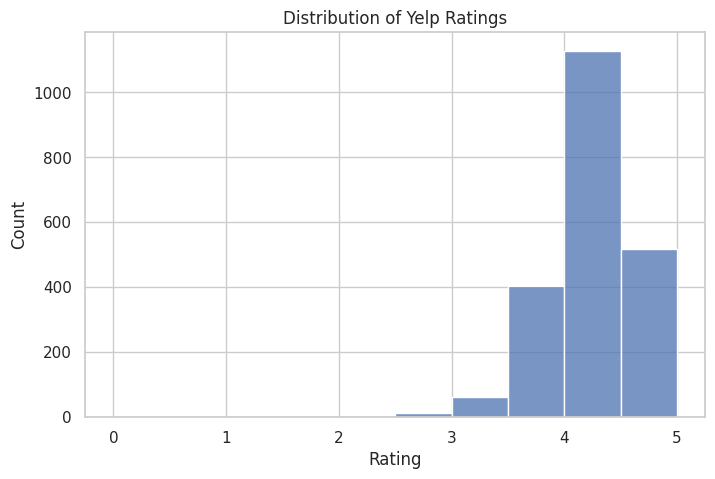

In [ ]:
# Most restaurants are concentrated between 4.0 and 4.5 ratings, indicating strong competition in Manhattan.

plt.figure(figsize=(8, 5))
sns.histplot(yelp_analysis["rating"], bins=10)
plt.title("Distribution of Yelp Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

**review count distribution**

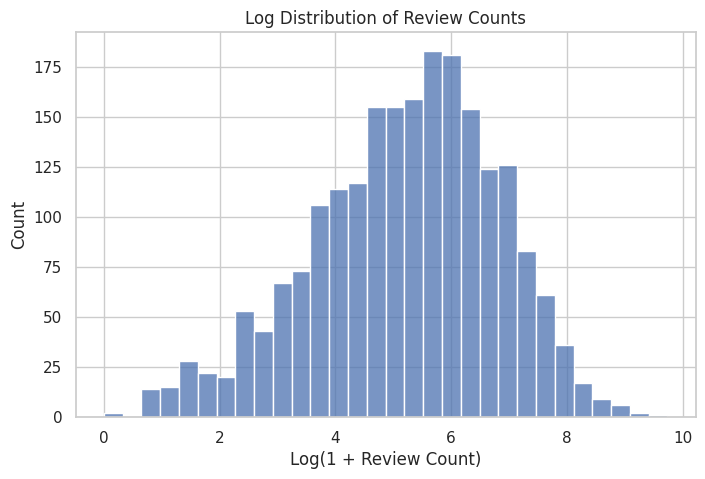

In [ ]:
# Review counts are highly skewed, with a small number of very popular restaurants.

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(yelp_analysis["review_count"]), bins=30)
plt.title("Log Distribution of Review Counts")
plt.xlabel("Log(1 + Review Count)")
plt.ylabel("Count")
plt.show()

### **II — Cuisine is the main segmentation variable**

**cuisine vs average rating**

In [ ]:
# We only keep cuisines with enough observations

cuisine_count = yelp_analysis["main_category"].value_counts()
top_cuisines = cuisine_count[cuisine_count >= 15].index

cuisine_df = yelp_analysis[yelp_analysis["main_category"].isin(top_cuisines)].copy()

cuisine_summary = cuisine_df.groupby("main_category").agg({
  "rating": "mean",
  "review_count": "mean",
  "price_level": "mean",
  "id": "count"}).rename(columns={"id": "restaurant_count"})

cuisine_summary = cuisine_summary.sort_values("rating", ascending=False)

print(cuisine_summary.head(20))

                      rating  review_count  price_level  restaurant_count
main_category                                                            
Sushi Bars          4.387179    329.487179     2.905660               117
Japanese            4.302703    422.711712     2.576271               111
Ramen               4.285185   1213.666667     2.086957                27
Mediterranean       4.285000    355.200000     2.166667                20
Desserts            4.280000    701.200000     1.500000                15
Seafood             4.280000    469.600000     2.857143                15
Korean              4.255652    586.113043     2.635135               115
Thai                4.222727    633.300000     2.120000               110
Pizza               4.217568    599.155405     1.567901               148
Bars                4.208511    374.936170     2.285714                47
Tacos               4.205000    564.500000     1.900000                20
Cocktail Bars       4.186885    427.06

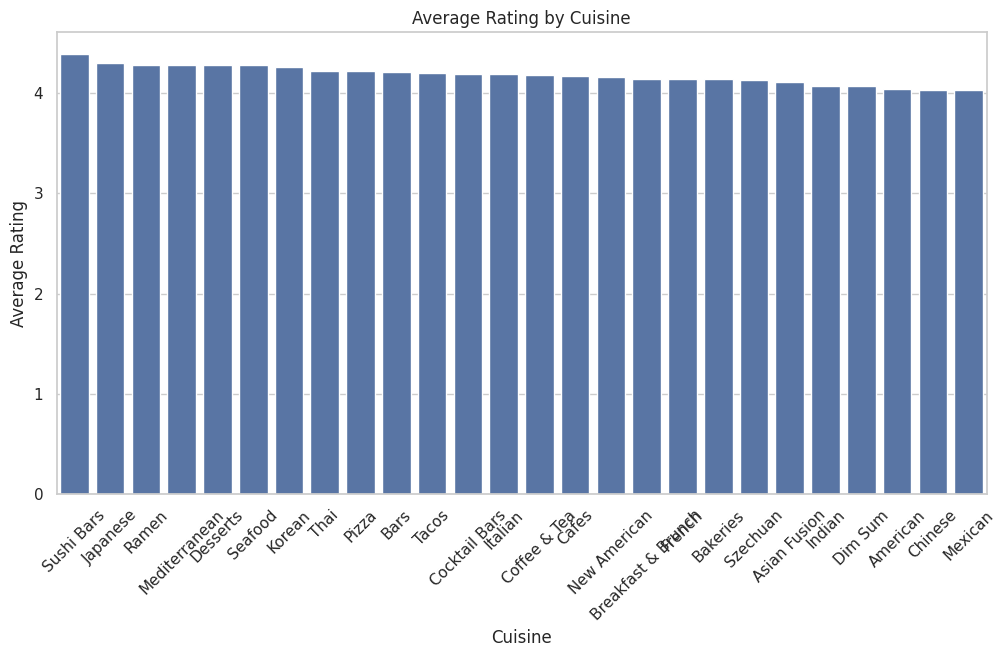

In [ ]:
# Seafood、Sushi Bars、Ramen、Japanese、Korean、Italian 是 Yelp 上表现最强的一批 cuisine。
# Italian worth to be emphasized the most, with 4.26 rating under 139 samples, indicating strong reliability and consistency
# Sushi Bars、Korean、Thai have a high propotion of 4.5+ ratings, indicating that restaurants of high ratings have higher probability to appear within these cuisine types
# The advantages of Italian、Ramen are not just high rating avergae, but also relative solid in consistency
# Mediterranean have high averge but the sample is too small(16), can only be seen as “promising but less conclusive”。

plt.figure(figsize=(12, 6))
sns.barplot(
    data=cuisine_summary.reset_index(),
    x="main_category",
    y="rating"
)
plt.title("Average Rating by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

**cuisine rating distribution**

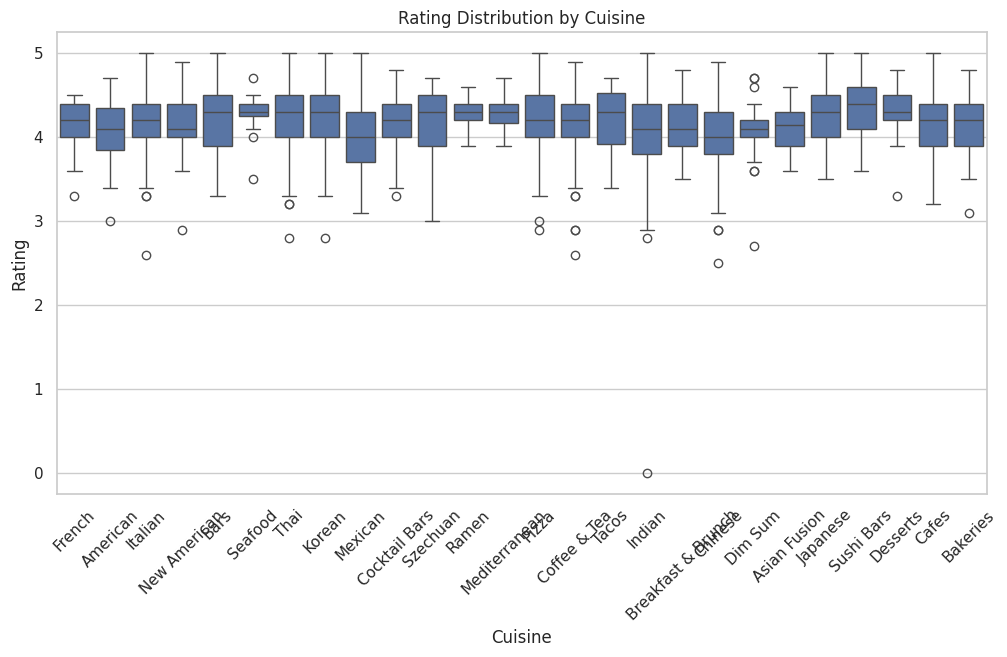

In [ ]:
# Only focusing on the average may be misleading, if two cisine types have same average but one have thinner box in the plot and the other have fatter one
# More consistent and predicatable ones are those that have high average, thin box, and few outliers

plt.figure(figsize=(12, 6))
sns.boxplot(data=cuisine_df, x="main_category", y="rating")
plt.title("Rating Distribution by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.show()

**cuisine rating structure**

In [ ]:
# Is the high rating because of most restaurants have high ratings, or due to only a few restaurants have extremely high ratings？
# Is a high average rating caused by widespread strong ratings, or by only a few very highly rated restaurants?

rating_structure = cuisine_df.groupby("main_category").agg(
    mean_rating=("rating", "mean"),
    std_rating=("rating", "std"),
    restaurant_count=("id", "count"),
    share_4plus=("rating", lambda x: (x >= 4.0).mean() * 100),
    share_45plus=("rating", lambda x: (x >= 4.5).mean() * 100),
    share_5only=("rating", lambda x: (x == 5.0).mean() * 100))

rating_structure = rating_structure.sort_values("mean_rating", ascending=False)

print(rating_structure.head(20))

                    mean_rating  std_rating  restaurant_count  share_4plus  share_45plus  share_5only
main_category                                                                                        
Sushi Bars             4.387179    0.333874               117    87.179487     46.153846     1.709402
Japanese               4.302703    0.343897               111    84.684685     34.234234     5.405405
Ramen                  4.285185    0.183353                27    96.296296     18.518519     0.000000
Mediterranean          4.285000    0.220705                20    90.000000     20.000000     0.000000
Desserts               4.280000    0.362925                15    86.666667     33.333333     0.000000
Seafood                4.280000    0.270449                15    93.333333     13.333333     0.000000
Korean                 4.255652    0.364954               115    84.347826     32.173913     0.869565
Thai                   4.222727    0.415670               110    77.272727     37.

In [ ]:
# Focus on top cuisines by average rating

focus_cuisines = list(rating_structure.head(8).index)

rating_band_df = cuisine_df[cuisine_df["main_category"].isin(focus_cuisines)].copy()

rating_band_table = rating_band_df.groupby(["main_category", "rating"])["id"].count().unstack(fill_value=0)

rating_band_pct = rating_band_table.div(rating_band_table.sum(axis=1), axis=0) * 100

print(rating_band_pct)

rating              2.8       3.2       3.3       3.4       3.5       3.6       3.7       3.8        3.9        4.0       4.1        4.2        4.3        4.4        4.5        4.6       4.7  \
main_category                                                                                                                                                                                    
Desserts       0.000000  0.000000  6.666667  0.000000  0.000000  0.000000  0.000000  0.000000   6.666667   6.666667  0.000000  13.333333  33.333333   0.000000  13.333333   6.666667  6.666667   
Japanese       0.000000  0.000000  0.000000  0.000000  1.801802  0.000000  0.900901  5.405405   7.207207  10.810811  9.009009  10.810811  13.513514   6.306306   9.909910   7.207207  5.405405   
Korean         0.869565  0.000000  0.869565  0.000000  4.347826  1.739130  0.869565  2.608696   4.347826  10.434783  6.956522   8.695652  14.782609  11.304348  13.913043   7.826087  3.478261   
Mediterranean  0.000000  0.000

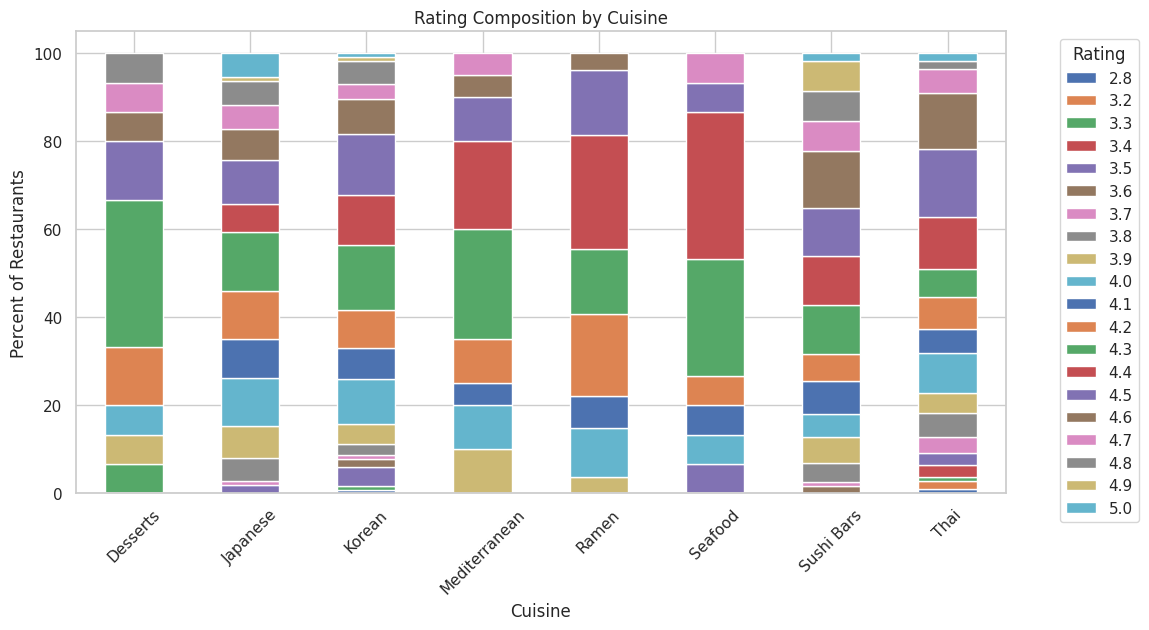

In [ ]:
# Stacked bar chart: rating composition

rating_band_pct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Rating Composition by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Percent of Restaurants")
plt.xticks(rotation=45)
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**cuisine vs review_count**

In [ ]:
# Ramen review_count is high，indicating high popularity
# French have high review，but the rating isn't necessary the highest
# Italian have both high rating and high review_count，is worth focusing.

cuisine_review_summary = cuisine_df.groupby("main_category").agg({
    "review_count": "mean",
    "rating": "mean",
    "id": "count"
}).rename(columns={"id": "restaurant_count"})

cuisine_review_summary = cuisine_review_summary.sort_values("review_count", ascending=False)

print(cuisine_review_summary.head(20))

                    review_count    rating  restaurant_count
main_category                                               
Ramen                1213.666667  4.285185                27
French                950.360000  4.144000                25
New American          736.465517  4.165517                58
Desserts              701.200000  4.280000                15
Italian               658.754190  4.186592               179
Thai                  633.300000  4.222727               110
Pizza                 599.155405  4.217568               148
Szechuan              595.222222  4.129630                27
Korean                586.113043  4.255652               115
Tacos                 564.500000  4.205000                20
Breakfast & Brunch    534.627451  4.145098                51
American              514.304348  4.039130                23
Asian Fusion          502.777778  4.111111                18
Bakeries              484.600000  4.142667                75
Seafood               46

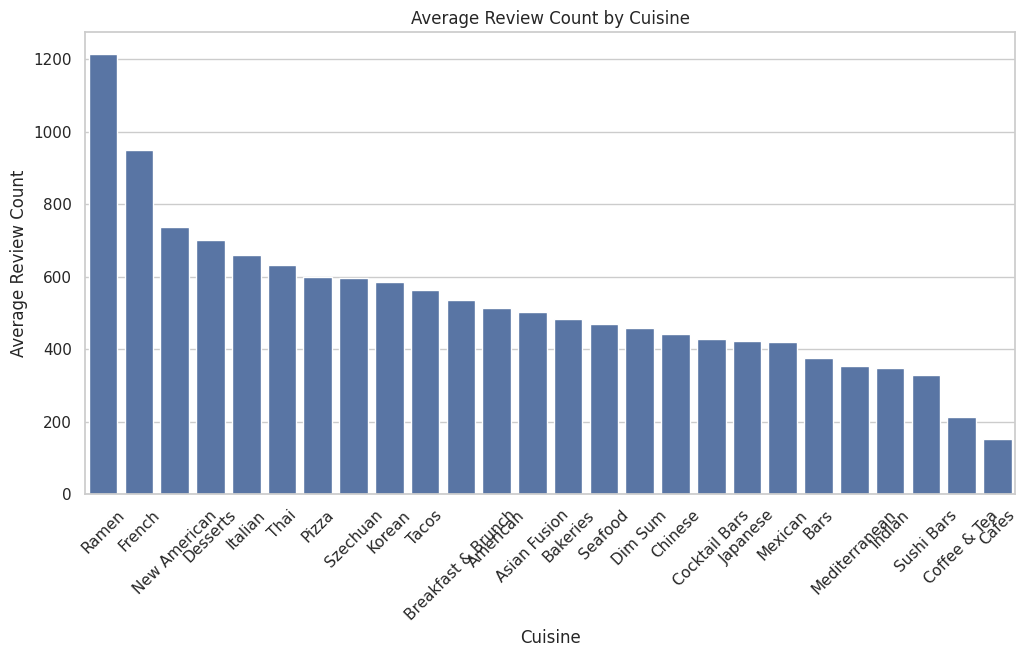

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=cuisine_review_summary.reset_index(),
    x="main_category",
    y="review_count")
plt.title("Average Review Count by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Review Count")
plt.xticks(rotation=45)
plt.show()

### **III — Location (Zip code)**

zip_code
10019    204
10003    168
10036    164
10001    155
10016    154
10022    129
10011    116
10018    110
10014     98
10012     85
Name: count, dtype: int64


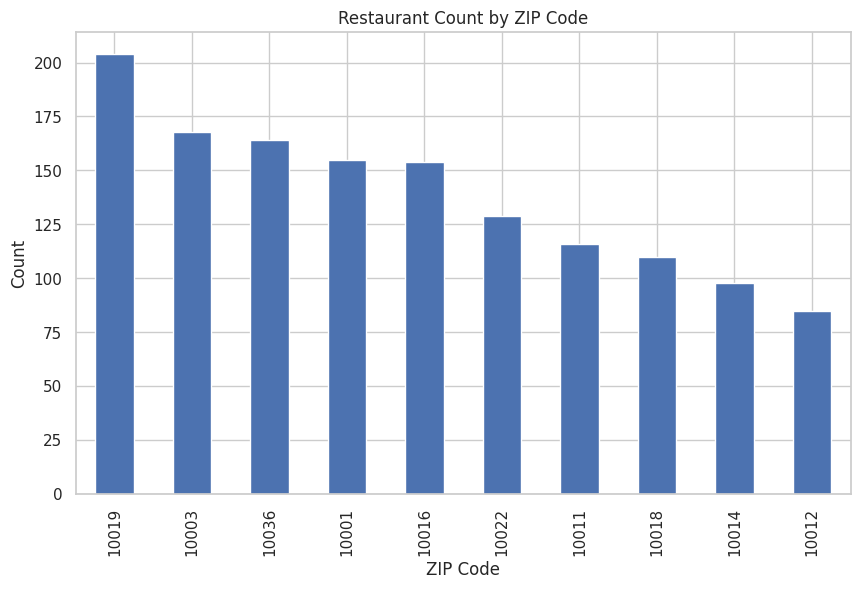

In [ ]:
# First look at restaurant count
# Restaurants in Manhattan are concentrated highly in several business centres.

zip_counts = yelp_analysis["zip_code"].value_counts().head(10)

print(zip_counts)

zip_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Restaurant Count by ZIP Code")
plt.xlabel("ZIP Code")
plt.ylabel("Count")
plt.show()

In [ ]:
# ZIP code summary:
# For investment analysis, count alone is not enough.
# We need average rating and average review_count too.

zip_summary = yelp_analysis.groupby("zip_code").agg({
    "rating": "mean",
    "review_count": "mean",
    "id": "count"
}).rename(columns={"id": "restaurant_count"})

zip_summary = zip_summary[zip_summary["restaurant_count"] >= 10].copy()
zip_summary = zip_summary.sort_values(["rating", "restaurant_count"], ascending=[False, False])

print(zip_summary.head(15))

            rating  review_count  restaurant_count
zip_code                                          
10009     4.383333    408.444444                54
10029     4.331579     94.052632                19
10002     4.275610    768.500000                82
10038     4.275000    250.800000                20
10007     4.260000    385.600000                10
10018     4.249091    397.727273               110
10016     4.230519    377.142857               154
10014     4.213265    701.734694                98
10011     4.206897    482.275862               116
10003     4.198214    635.928571               168
10019     4.187255    610.132353               204
10001     4.183871    541.767742               155
10036     4.183537    622.512195               164
10025     4.181356    315.542373                59
10017     4.180488    310.329268                82


In [ ]:
# Top 5 ZIP codes: deeper cuisine analysis
# Goal: find possible cuisine gaps and neighborhood specialization

top5_zip = list(zip_summary.head(5).index)

zip_cuisine = yelp_analysis[
    yelp_analysis["zip_code"].isin(top5_zip)
].groupby(["zip_code", "main_category"]).agg({
    "rating": "mean",
    "review_count": "mean",
    "id": "count"}).rename(columns={"id": "restaurant_count"}).reset_index()

zip_cuisine = zip_cuisine[zip_cuisine["restaurant_count"] >= 2].copy()

print(zip_cuisine.sort_values(["zip_code", "rating"], ascending=[True, False]).head(50))

   zip_code       main_category    rating  review_count  restaurant_count
11    10002            Desserts  4.650000    269.000000                 2
27    10002            Szechuan  4.550000    575.000000                 2
19    10002             Izakaya  4.500000    179.500000                 2
3     10002                Bars  4.400000    136.250000                 4
21    10002              Korean  4.400000    229.750000                 4
24    10002               Pizza  4.380000    312.600000                 5
28    10002                Thai  4.375000    422.000000                 4
17    10002              Indian  4.366667    609.000000                 3
26    10002          Sushi Bars  4.320000    418.400000                 5
20    10002            Japanese  4.280000    429.200000                 5
18    10002             Italian  4.275000    282.750000                 4
30    10002          Vietnamese  4.250000    433.500000                 2
8     10002             Chinese  4.242

In [ ]:
# ZIP code with most restaurants include 10019、10003、10016、10036、10022、10001。
# but is we look at average rating，10029、10002、10009、10007、10014 are more advantaged。
# Thus generally, zip codes with both high average ratings and restaurant numbers are 10019、10003、10016，followed by 10002、10018、10014。

In [ ]:
# Zip code affects market performance but more indicating partial market enviroment instead of individual quality

### **IV — Supporting factors: price and review counts**

**price**

               rating  review_count  restaurant_count
price_level                                          
1.0          4.136620    545.943662               142
2.0          4.076492    809.721957               838
3.0          4.141379    873.517241               232
4.0          4.275000    786.052632                76


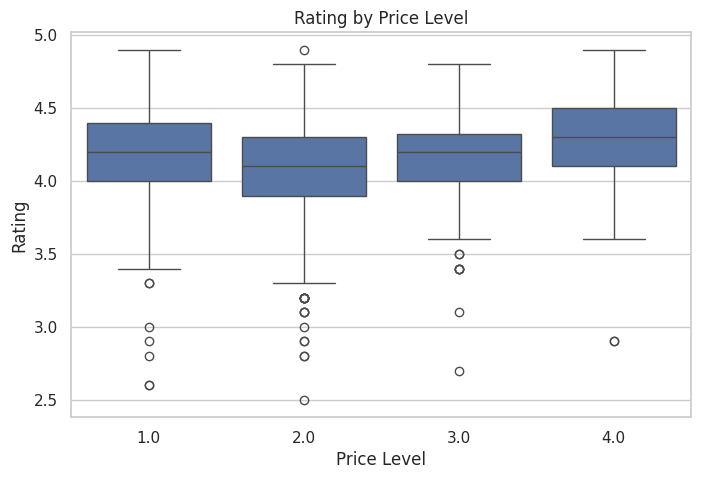

In [ ]:
# Higher price levels tend to have slightly higher ratings, but the difference is not dramatic.

price_df = yelp_analysis.dropna(subset=["price_level"]).copy()

price_summary = price_df.groupby("price_level").agg({
    "rating": "mean",
    "review_count": "mean",
    "id": "count"}).rename(columns={"id": "restaurant_count"})

print(price_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=price_df, x="price_level", y="rating")
plt.title("Rating by Price Level")
plt.xlabel("Price Level")
plt.ylabel("Rating")
plt.show()

In [ ]:
# Fine dining are more likely to receive high ratings高端餐厅更容易获得更高评分。
# but we cannot conclude higher price-higher rating as the difference in 1.0 to 3.0 is unlinear
# Furthermore, there are many empty values, so we only see this as a subsample analysis

**review** **count**

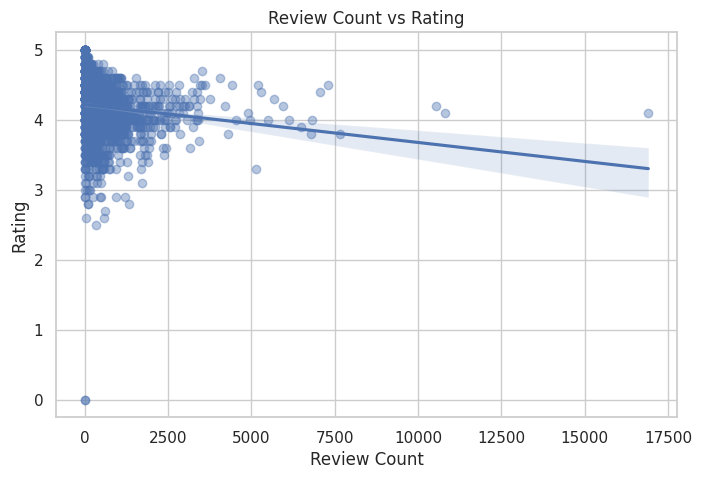

In [ ]:
# No strong relationship

plt.figure(figsize=(8, 5))
sns.regplot(data=yelp_analysis, x="review_count", y="rating", scatter_kws={"alpha": 0.4})
plt.title("Review Count vs Rating")
plt.xlabel("Review Count")
plt.ylabel("Rating")
plt.show()

### **V — Operational stability from NYC inspection data**

In [ ]:
# Important: lower score is better

**Inspection score distribution**

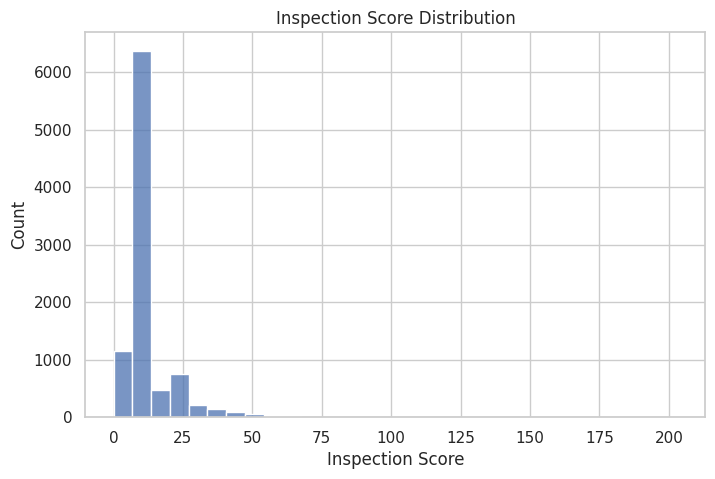

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(inspection_latest["score"], bins=30)
plt.title("Inspection Score Distribution")
plt.xlabel("Inspection Score")
plt.ylabel("Count")
plt.show()

**Grade distribution**

grade
A    7365
N     723
B     703
Z     273
C     265
P      23
Name: count, dtype: int64


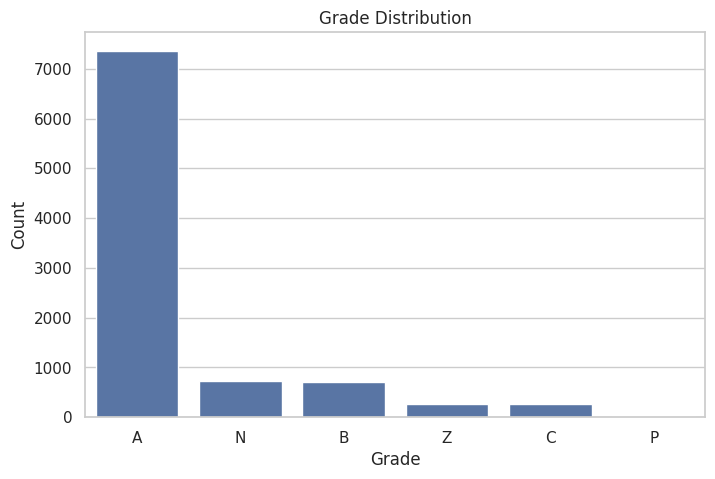

In [ ]:
grade_summary = inspection_latest["grade"].value_counts(dropna=False)
print(grade_summary)

plt.figure(figsize=(8, 5))
sns.countplot(data=inspection_latest, x="grade", order=inspection_latest["grade"].value_counts().index)
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

**Cuisine vs inspection score**

In [ ]:
# Keep cuisines with enough observations
# some cuisine market are more likely to keep low inspection score
# Cuisine types with more standardized operations and lower preparation complexity tend to manage hygiene risks more effectively such as beverages, desserts, and standardized fast-casual formats.
# In contrast, cuisines with higher preparation complexity, longer ingredient chains, and stricter cold and hot storage requirements face greater challenges in maintaining low inspection scores.

top_ins_cuisines = inspection_latest["cuisine_description"].value_counts()
top_ins_cuisines = top_ins_cuisines[top_ins_cuisines >= 15].index

ins_cuisine_df = inspection_latest[
    inspection_latest["cuisine_description"].isin(top_ins_cuisines)
].copy()

ins_cuisine_summary = ins_cuisine_df.groupby("cuisine_description").agg({
    "score": "mean",
    "violation_count": "mean",
    "critical_violation_count": "mean",
    "camis": "count"
}).rename(columns={"camis": "restaurant_count"})

ins_cuisine_summary = ins_cuisine_summary.sort_values("score")

print(ins_cuisine_summary.head(20))

                                    score  violation_count  critical_violation_count  restaurant_count
cuisine_description                                                                                   
Donuts                           8.973510         1.364238                  0.509934               151
Salads                           9.974684         1.468354                  0.645570                79
Hamburgers                      10.435115         1.465649                  0.610687               131
Soups/Salads/Sandwiches         10.896552         1.379310                  0.413793                29
Bottled Beverages               11.166667         1.333333                  0.595238                42
Vegetarian                      11.315789         1.421053                  0.736842                19
Tex-Mex                         11.438596         1.500000                  0.508772               114
Bakery Products/Desserts        11.445255         1.481752               

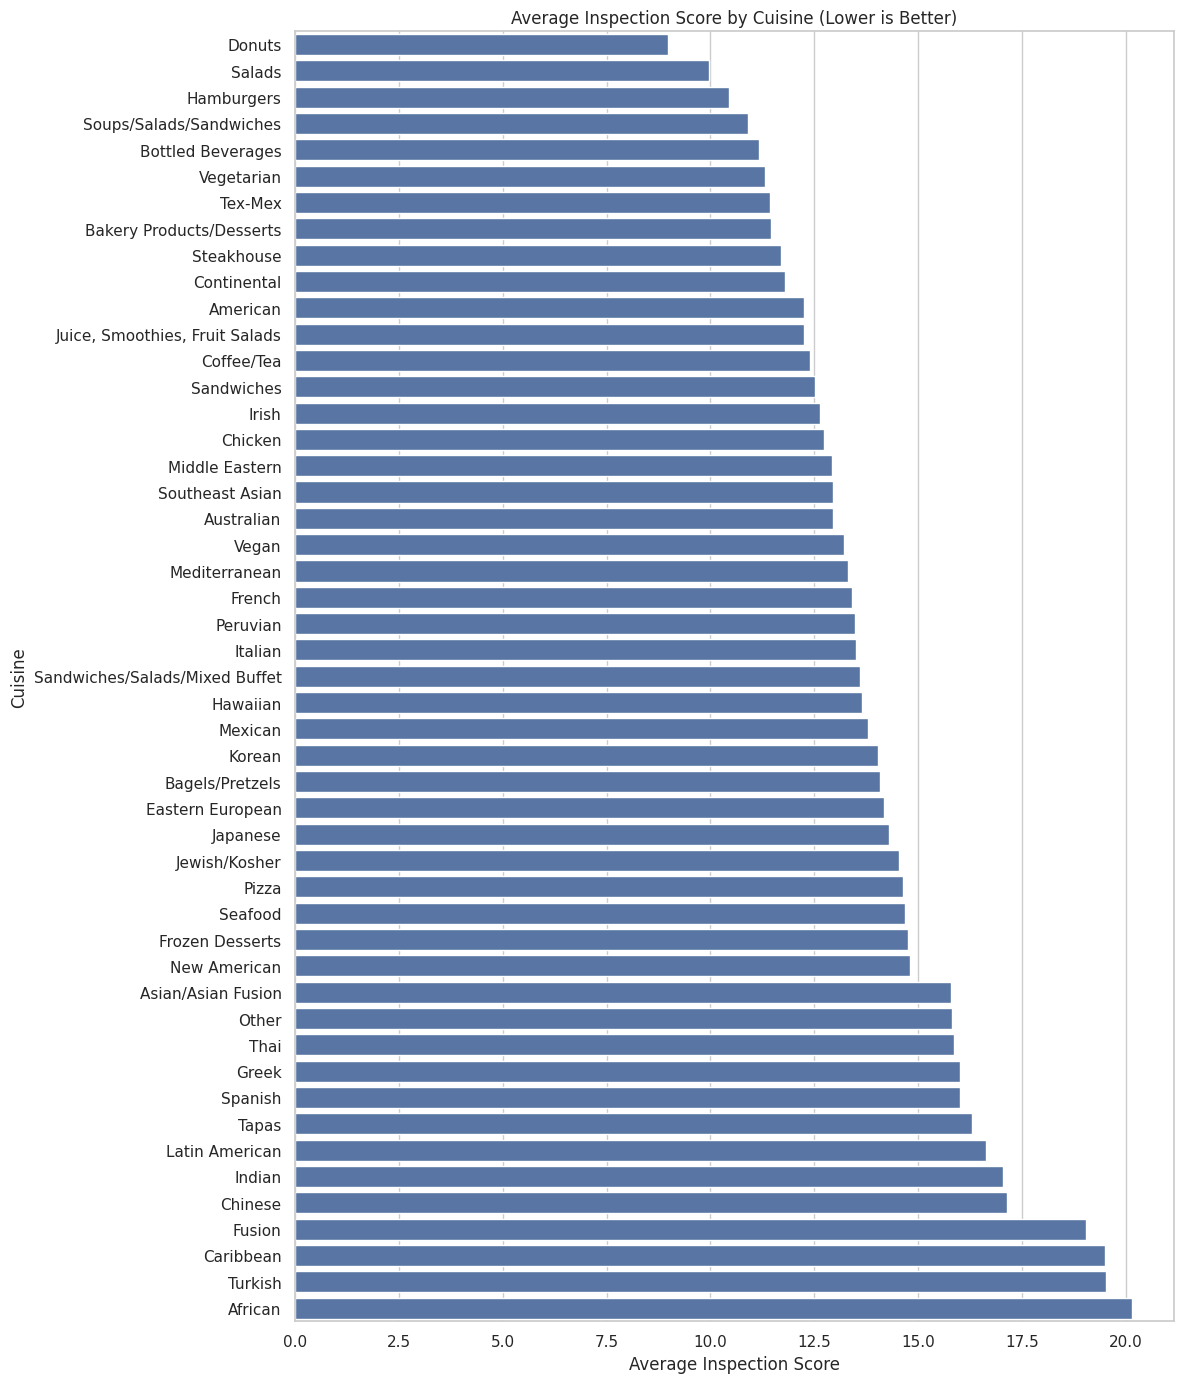

In [ ]:
plt.figure(figsize=(12, 14))

plot_data = ins_cuisine_summary.reset_index().sort_values("score", ascending=True)

sns.barplot(data=plot_data, y="cuisine_description", x="score")

plt.title("Average Inspection Score by Cuisine (Lower is Better)")
plt.xlabel("Average Inspection Score")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()

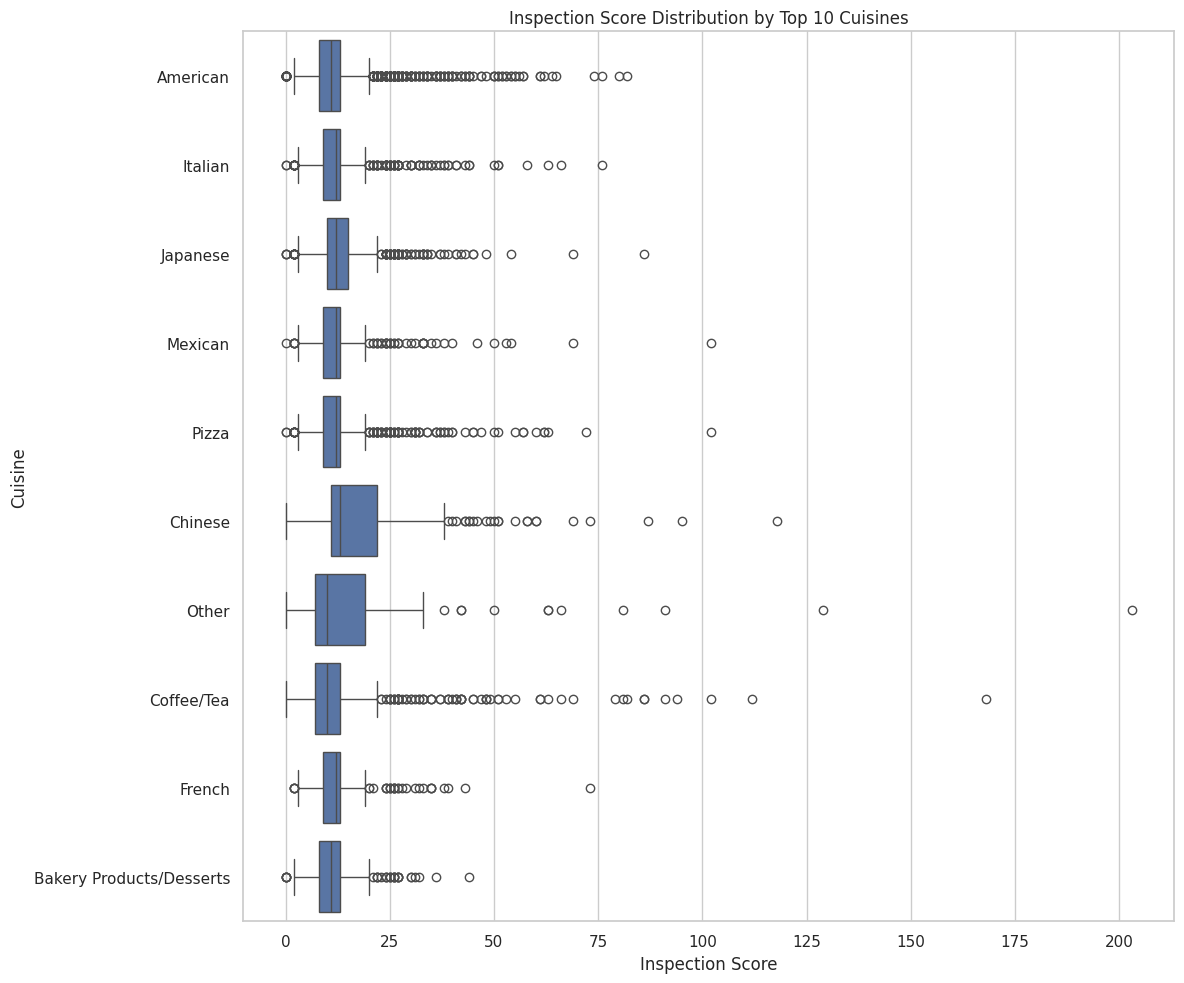

In [ ]:
cuisine_count = ins_cuisine_df["cuisine_description"].value_counts()
top10_cuisine = cuisine_count.head(10).index

plot_data = ins_cuisine_df[ins_cuisine_df["cuisine_description"].isin(top10_cuisine)]

plt.figure(figsize=(12, 10))
sns.boxplot(data=plot_data, y="cuisine_description", x="score")

plt.title("Inspection Score Distribution by Top 10 Cuisines")
plt.xlabel("Inspection Score")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()

**critical violations vs score**

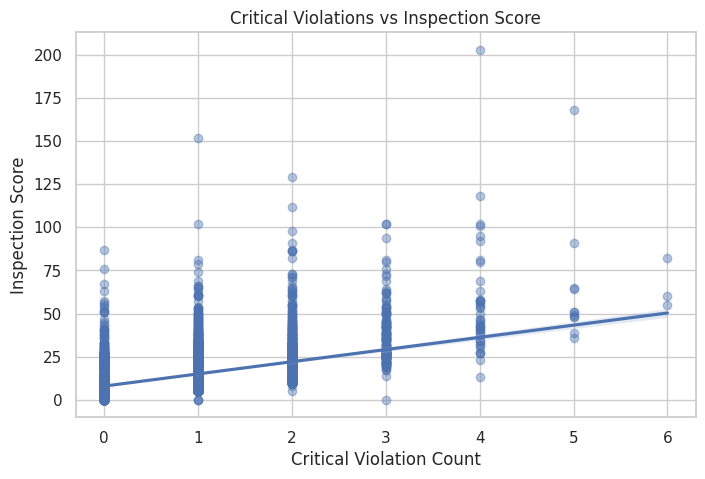

In [ ]:
# Critical violations vs score

plt.figure(figsize=(8, 5))
sns.regplot(data=inspection_latest, x="critical_violation_count", y="score", scatter_kws={"alpha": 0.4})
plt.title("Critical Violations vs Inspection Score")
plt.xlabel("Critical Violation Count")
plt.ylabel("Inspection Score")
plt.show()

**most common violation types**

In [ ]:
# We use raw inspection_clean here because violation_description is a row-level variable

top_violations = inspection_clean["violation_description"].value_counts().head(10)

print(top_violations)

violation_description
Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.                                                                6643
Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.                                                                                                                                                                                     3951
Food contact surface not properly washed, rinsed and sanitized after each use and following any activity when contamination may have occurred.                                                                                                                                         3423
Anti-siphonage or back-flow prevention device not provided where required; equipment or floor not properly drained; sewage dis

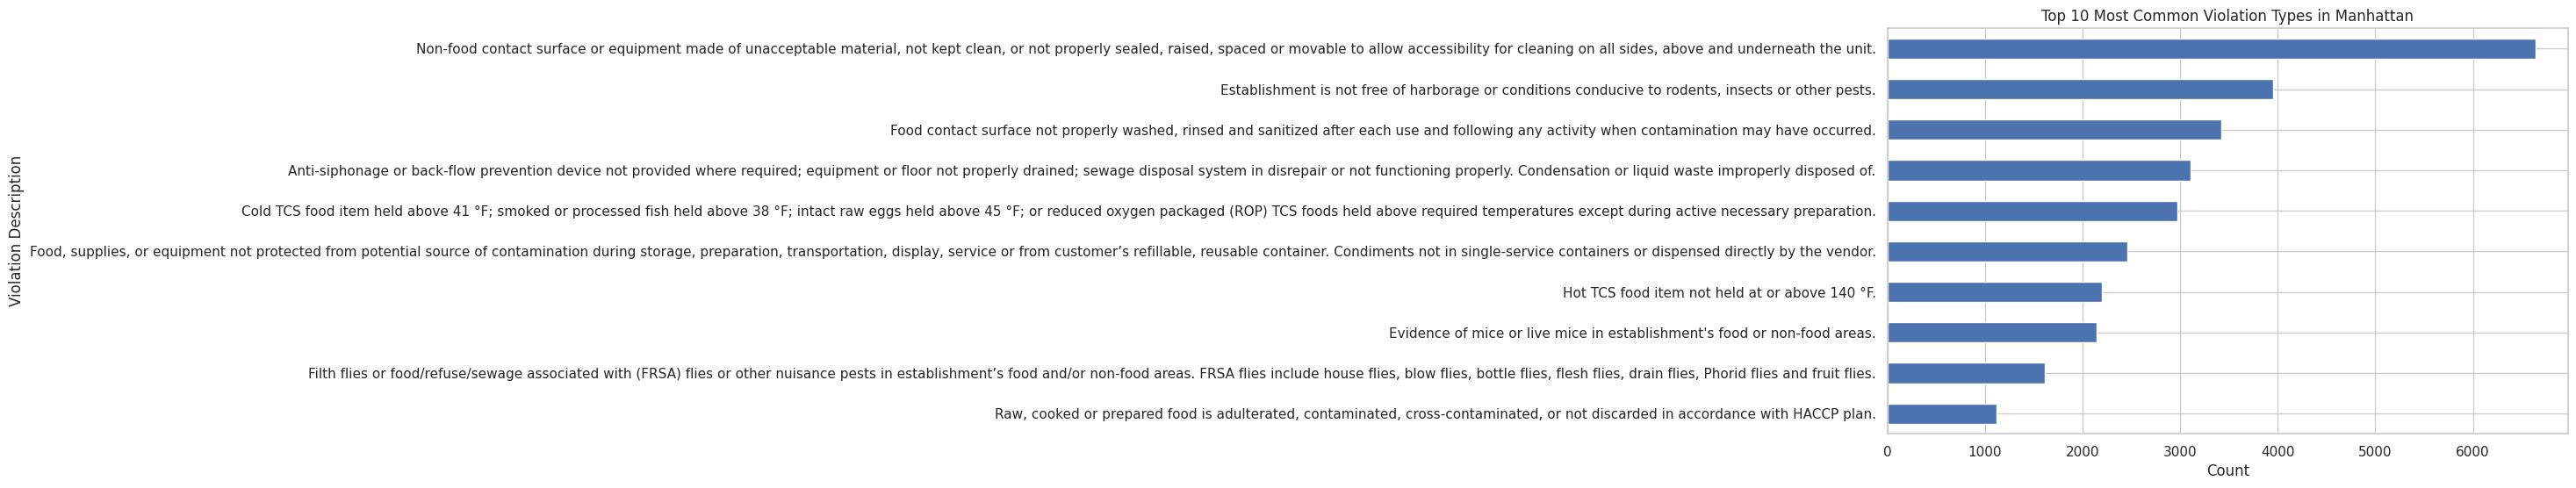

In [ ]:
# We can mainly conclude violation risk into 4 types:
# sanitation and equipment maintenance, pest control, temperature control, and cross-contamination and food safety procedures.

plt.figure(figsize=(10, 6))
top_violations.sort_values().plot(kind="barh")
plt.title("Top 10 Most Common Violation Types in Manhattan")
plt.xlabel("Count")
plt.ylabel("Violation Description")
plt.show()

## **Step 5 Synthesis — Which restaurant segments look most promising?**

A. safer / more stable segments

(Not necessary best from Yelp dataset only
but inspection score is more solid
better price
their business mode are easier to copy)

Coffee/Tea

Cafes

Bakeries

some healthy food/drinks

B. higher-upside but more execution-sensitive

(strong in Yelp
high attraction to consumers
may be more complex to operate，and not necessarily best in inspection)


Italian

Sushi Bars / Japanese

Korean

Ramen

Thai

C. Location conclusion


10019 / 10003 / 10016：markets that are more mature with larger scale

10002 / 10014 / 10029：area with opprtunities to appear high rating and specialty

## **Step 6 Additional research questions for depth**

### **Q1. Correlation analysis**

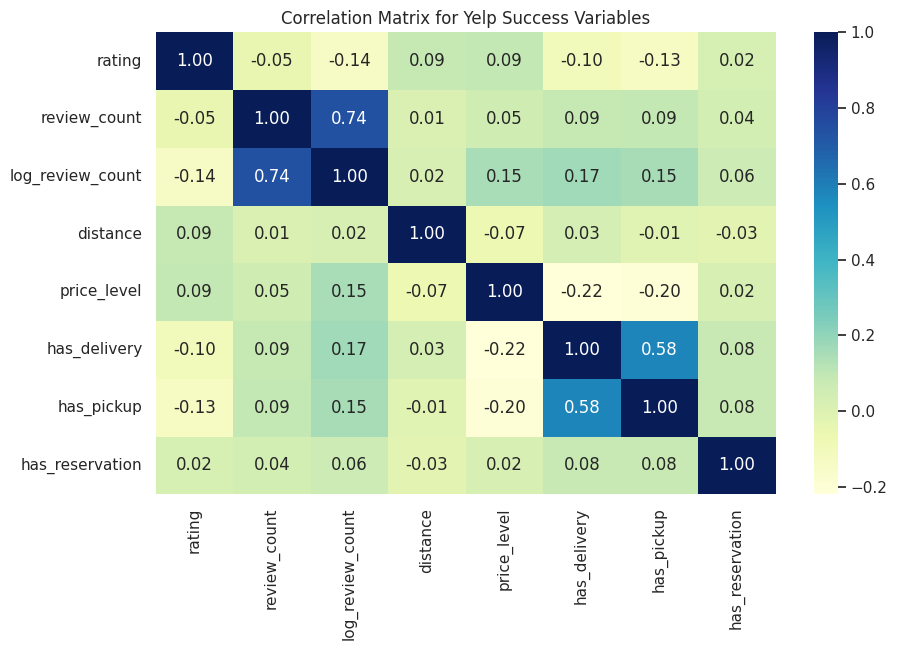

In [ ]:
# Correlation matrix for rating-related variables
# which variable is more correlated with rating linearly
# price_level and rating have some positive correlation
# review_count and rating may be weaker positive correlation
# distance and rating have weak correlation
# service-related variables and rating almost don't have linear correkation

# note that correlation doesn't mean causation

yelp_analysis["log_review_count"] = np.log1p(yelp_analysis["review_count"])

corr_df = yelp_analysis[
    ["rating", "review_count", "log_review_count", "distance",
     "price_level", "has_delivery", "has_pickup", "has_reservation"]
].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Matrix for Yelp Success Variables")
plt.show()

### **Q2. Zip code with success**

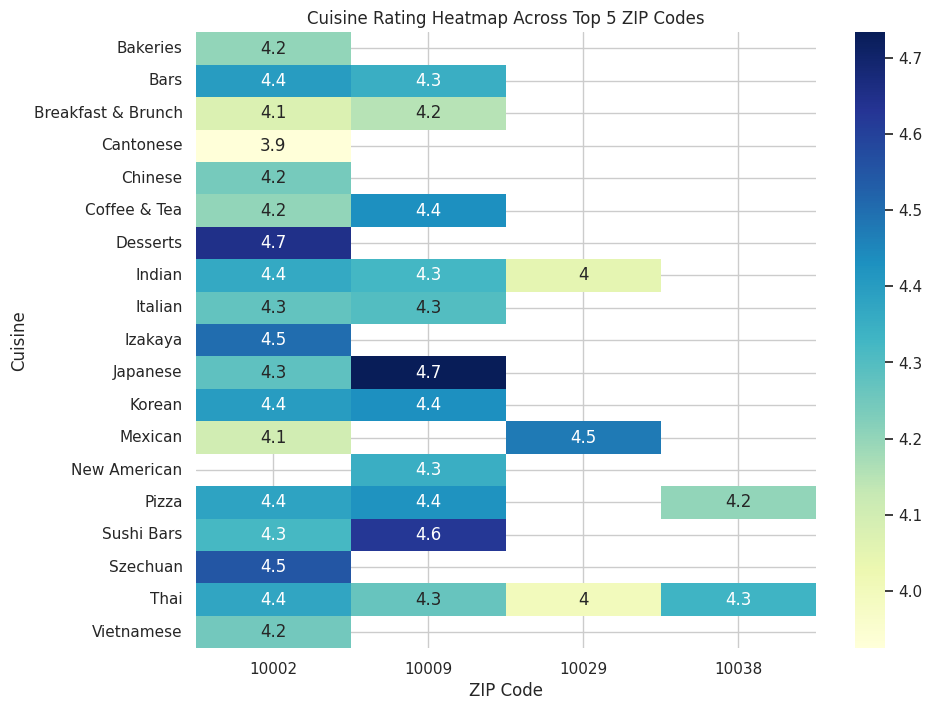

In [ ]:
# ZIP code x cuisine rating heatmap

zip_cuisine_pivot = zip_cuisine.pivot(
    index="main_category",
    columns="zip_code",
    values="rating"
)

plt.figure(figsize=(10, 8))
sns.heatmap(zip_cuisine_pivot, annot=True, cmap="YlGnBu")
plt.title("Cuisine Rating Heatmap Across Top 5 ZIP Codes")
plt.xlabel("ZIP Code")
plt.ylabel("Cuisine")
plt.show()

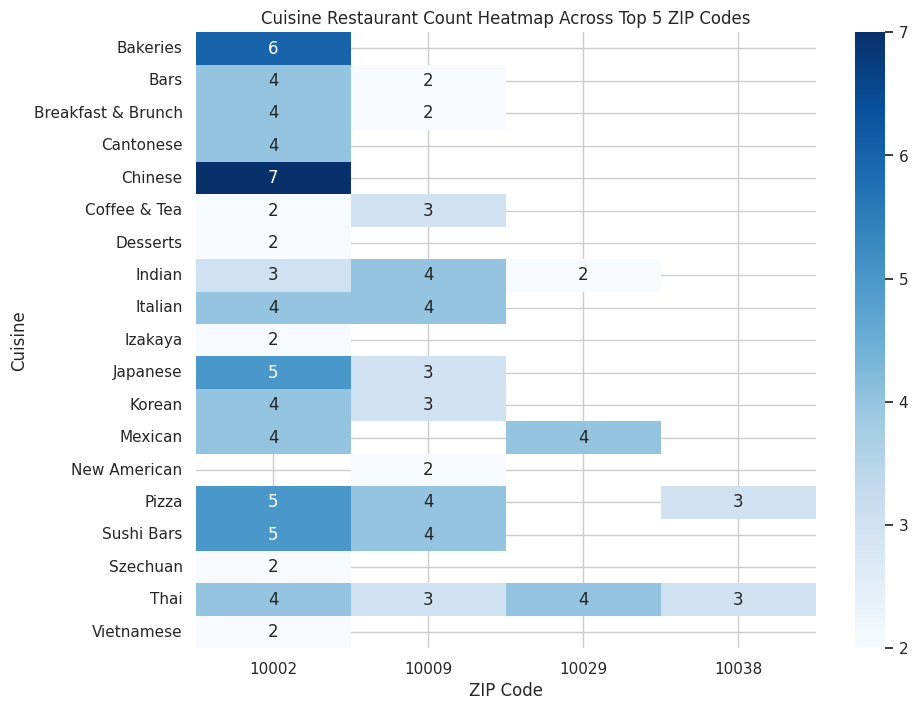

In [ ]:
# ZIP code x cuisine restaurant count heatmap
# This helps detect possible local cuisine gaps

zip_cuisine_count_pivot = zip_cuisine.pivot(
    index="main_category",
    columns="zip_code",
    values="restaurant_count"
)

plt.figure(figsize=(10, 8))
sns.heatmap(zip_cuisine_count_pivot, annot=True, cmap="Blues")
plt.title("Cuisine Restaurant Count Heatmap Across Top 5 ZIP Codes")
plt.xlabel("ZIP Code")
plt.ylabel("Cuisine")
plt.show()

### **Q3. Within the same price level, which cuisines perform better?**

In [ ]:
cuisine_price_summary = price_df.groupby(["price_level", "main_category"]).agg(
    mean_rating=("rating", "mean"),
    mean_review_count=("review_count", "mean"),
    restaurant_count=("id", "count")
).reset_index()

# keep only groups with enough observations
cuisine_price_summary = cuisine_price_summary[
    cuisine_price_summary["restaurant_count"] >= 5
].copy()

print(cuisine_price_summary.sort_values(["price_level", "mean_rating"], ascending=[True, False]).head(40))

     price_level       main_category  mean_rating  mean_review_count  restaurant_count
19           1.0             Mexican     4.328571         206.571429                 7
4            1.0               Cafes     4.300000         183.625000                 8
2            1.0            Bakeries     4.194118         432.470588                17
5            1.0             Chinese     4.160000         532.600000                 5
6            1.0        Coffee & Tea     4.137931         277.724138                29
21           1.0               Pizza     4.063158         903.236842                38
15           1.0              Indian     3.907692         458.846154                13
81           2.0       Mediterranean     4.300000        1001.800000                 5
107          2.0           Taiwanese     4.280000         653.800000                 5
87           2.0             Noodles     4.266667         270.500000                 6
30           2.0              Bagels     4.

In [ ]:
# Show top cuisines within each price level

for p in sorted(cuisine_price_summary["price_level"].dropna().unique()):
    print("\n" + "=" * 60)
    print("Price level:", p)
    print("=" * 60)

    one_price = cuisine_price_summary[cuisine_price_summary["price_level"] == p].copy()
    one_price = one_price.sort_values("mean_rating", ascending=False)

    print(one_price.head(10))


Price level: 1.0
    price_level main_category  mean_rating  mean_review_count  restaurant_count
19          1.0       Mexican     4.328571         206.571429                 7
4           1.0         Cafes     4.300000         183.625000                 8
2           1.0      Bakeries     4.194118         432.470588                17
5           1.0       Chinese     4.160000         532.600000                 5
6           1.0  Coffee & Tea     4.137931         277.724138                29
21          1.0         Pizza     4.063158         903.236842                38
15          1.0        Indian     3.907692         458.846154                13

Price level: 2.0
     price_level  main_category  mean_rating  mean_review_count  restaurant_count
81           2.0  Mediterranean     4.300000        1001.800000                 5
107          2.0      Taiwanese     4.280000         653.800000                 5
87           2.0        Noodles     4.266667         270.500000               

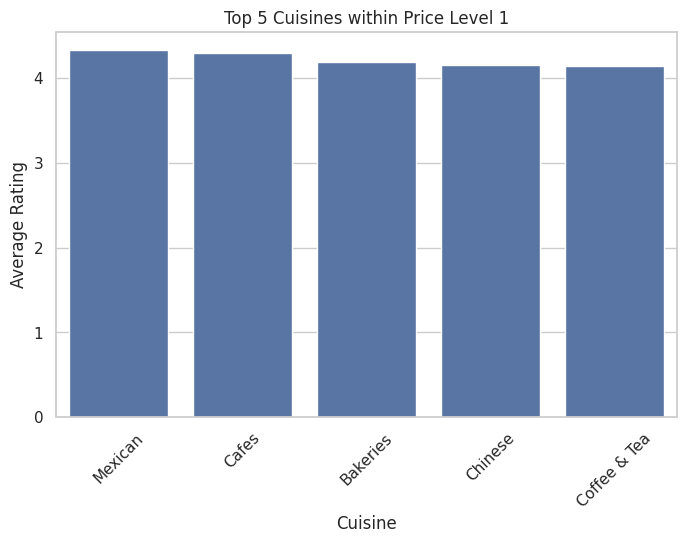

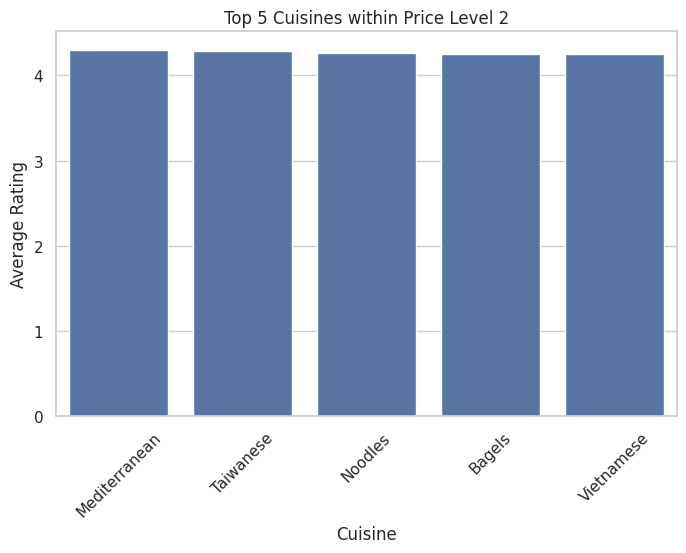

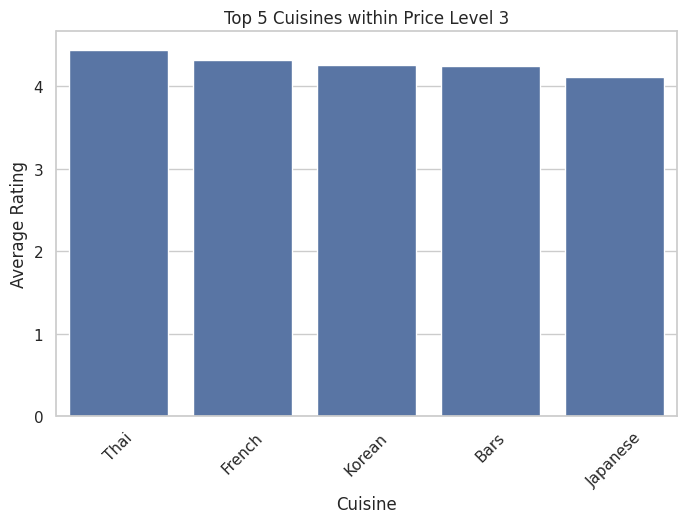

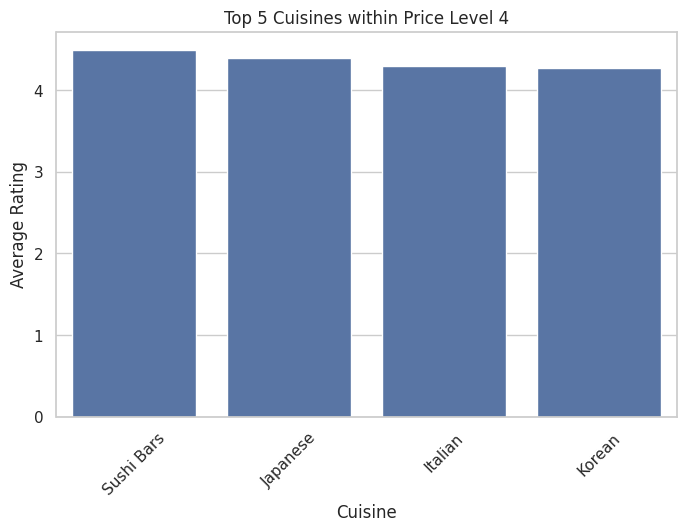

In [ ]:
# Visualization: top 5 cuisines within each price level

for p in sorted(cuisine_price_summary["price_level"].dropna().unique()):
    one_price = cuisine_price_summary[cuisine_price_summary["price_level"] == p].copy()
    one_price = one_price.sort_values("mean_rating", ascending=False).head(5)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=one_price, x="main_category", y="mean_rating")
    plt.title("Top 5 Cuisines within Price Level " + str(int(p)))
    plt.xlabel("Cuisine")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.show()

### **Q4. Common dishes / ingredient characteristics in highly rated cuisines**

In [ ]:
# Common dish patterns in highly rated cuisines

# IMPORTANT:
# This is a cuisine-level supplementary analysis.
# It does NOT claim to represent the exact menus of Manhattan restaurants.
# Instead, it uses dish titles from a supplementary API to identify
# common dish keywords and dish phrases in highly rated cuisines.

In [ ]:
# Match Yelp high-rating cuisines to cuisines available in TheMealDB

available_area_map = {
    "Thai": "Thai",
    "Italian": "Italian",
    "Indian": "Indian",
    "Japanese": "Japanese",
    "Mexican": "Mexican",
    "American": "American"}

In [ ]:
# Build a cuisine table from Yelp results
# We only keep cuisines with enough observations

top_cuisine_table = cuisine_summary.reset_index().copy()
top_cuisine_table = top_cuisine_table[top_cuisine_table["restaurant_count"] >= 15].copy()
top_cuisine_table = top_cuisine_table.sort_values("rating", ascending=False)

print("Top Yelp cuisines with enough observations:")
print(top_cuisine_table.head(20))

Top Yelp cuisines with enough observations:
         main_category    rating  review_count  price_level  restaurant_count
0           Sushi Bars  4.387179    329.487179     2.905660               117
1             Japanese  4.302703    422.711712     2.576271               111
2                Ramen  4.285185   1213.666667     2.086957                27
3        Mediterranean  4.285000    355.200000     2.166667                20
4             Desserts  4.280000    701.200000     1.500000                15
5              Seafood  4.280000    469.600000     2.857143                15
6               Korean  4.255652    586.113043     2.635135               115
7                 Thai  4.222727    633.300000     2.120000               110
8                Pizza  4.217568    599.155405     1.567901               148
9                 Bars  4.208511    374.936170     2.285714                47
10               Tacos  4.205000    564.500000     1.900000                20
11       Cocktail Ba

In [ ]:
# Keep only cuisines that can be matched to TheMealDB

matched_cuisines = []

for cuisine_name in list(top_cuisine_table["main_category"]):
  if cuisine_name in available_area_map:
    matched_cuisines.append(cuisine_name)

print("Matched cuisines for Step 8:")
print(matched_cuisines)

Matched cuisines for Step 8:
['Japanese', 'Thai', 'Italian', 'Indian', 'American', 'Mexican']


In [ ]:
# Select top matched cuisines for analysis

selected_planA_cuisines = matched_cuisines[:6]

print("Selected cuisines for dish-pattern analysis:")
print(selected_planA_cuisines)

Selected cuisines for dish-pattern analysis:
['Japanese', 'Thai', 'Italian', 'Indian', 'American', 'Mexican']


In [ ]:
# Function to get meals by cuisine area from TheMealDB

def get_area_meals(area_name):
    url = "https://www.themealdb.com/api/json/v1/1/filter.php?a=" + area_name
    response = requests.get(url)

    if response.status_code == 200:
      data = response.json()

      if "meals" in data and data["meals"] is not None:
        return data["meals"]
      else:
        return []
    else:
      return []

In [ ]:
# Stopwords: words we do NOT want to dominate the result
# We remove seasoning / generic words / less meaningful words

dish_stopwords = [
    "and", "with", "the", "a", "an", "of", "in", "on", "style",
    "garlic", "salt", "pepper", "oil", "olive", "butter", "sauce",
    "red", "green", "black", "white", "fresh", "hot", "cold",
    "classic", "traditional", "easy", "best"]

In [ ]:
# First, show the raw dish titles in each cuisine

for cuisine_name in selected_planA_cuisines:
    print("\n" + "=" * 70)
    print("Cuisine:", cuisine_name)
    print("=" * 70)

    area_name = available_area_map[cuisine_name]
    meals = get_area_meals(area_name)

    print("Number of meals returned by API:", len(meals))

    meal_title_list = []

    for meal in meals:
        meal_title_list.append(meal["strMeal"])

    meal_title_df = pd.DataFrame({"dish_title": meal_title_list})

    print("\nSample dish titles:")
    print(meal_title_df.head(20))


Cuisine: Japanese
Number of meals returned by API: 9

Sample dish titles:
                   dish_title
0             Chicken Karaage
1       Honey Teriyaki Salmon
2         Japanese gohan rice
3           Japanese Katsudon
4         Katsu Chicken curry
5                       Sushi
6  Teriyaki Chicken Casserole
7               Tonkatsu pork
8                   Yaki Udon

Cuisine: Thai
Number of meals returned by API: 27

Sample dish titles:
                                    dish_title
0                Drunken noodles (pad kee mao)
1            Lemongrass beef stew with noodles
2                          Massaman Beef curry
3                                   Pad See Ew
4                                     Pad Thai
5      Panang chicken curry (kaeng panang gai)
6                               Prawn stir-fry
7                     Red curry chicken kebabs
8                     Spicy Thai prawn noodles
9     Stir-fried chicken with chillies & basil
10                          Thai bee


Cuisine: Japanese

Top dish keywords:
   dish_keyword  count
0       chicken      3
3      teriyaki      2
5      japanese      2
2         honey      1
1       karaage      1
4        salmon      1
6         gohan      1
7          rice      1
8      katsudon      1
9         katsu      1
10        curry      1
11        sushi      1
12    casserole      1
13     tonkatsu      1
14         pork      1


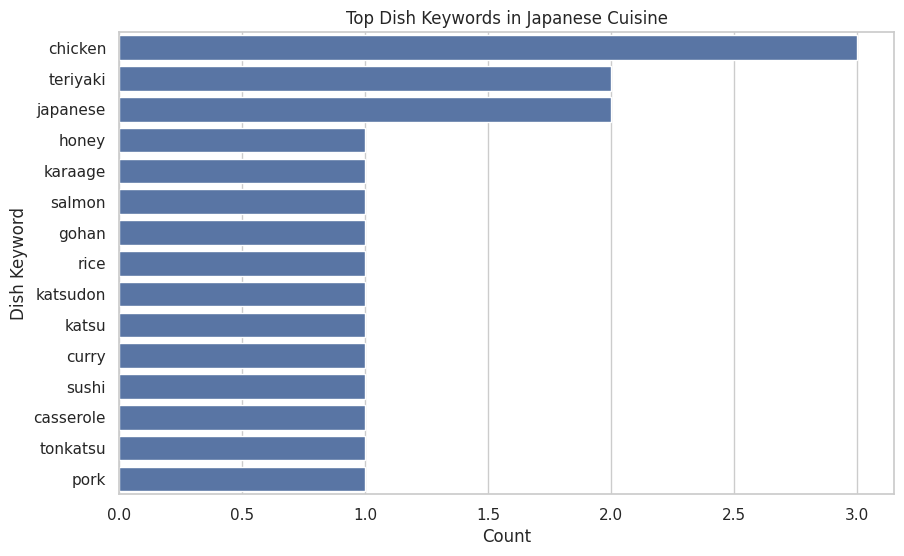


Cuisine: Thai

Top dish keywords:
   dish_keyword  count
11         thai     16
9         curry      7
13      chicken      5
31         soup      5
2           pad      3
6          beef      3
1       noodles      3
17         stir      3
34       prawns      3
16        prawn      3
43          tom      3
18          fry      2
15          gai      2
21        fried      2
12       panang      2


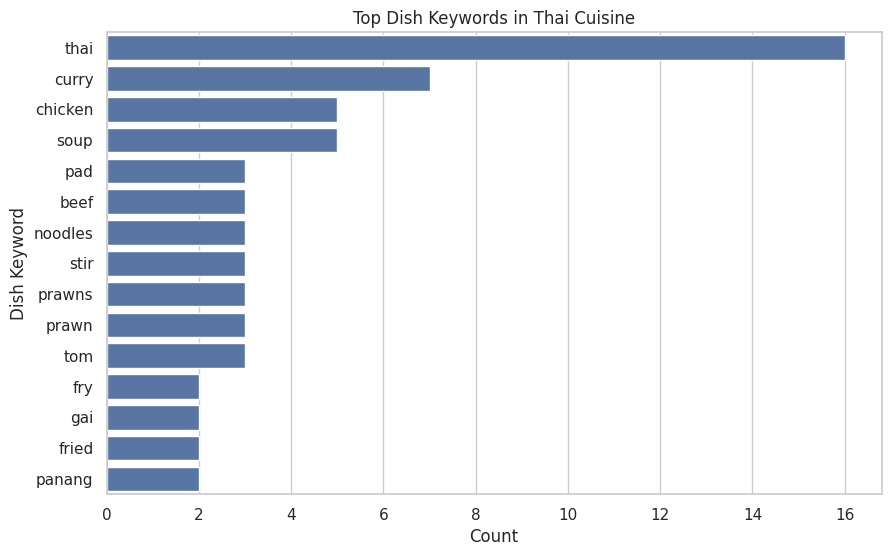


Cuisine: Italian

Top dish keywords:
     dish_keyword  count
3         alfredo      3
2         chicken      2
1         ricotta      2
7        linguine      2
6           prawn      2
31      spaghetti      2
16           alla      2
4       primavera      1
0          budino      1
9       fettucine      1
10        lasagne      1
5          chilli      1
8      fettuccine      1
12          pasta      1
11  mediterranean      1


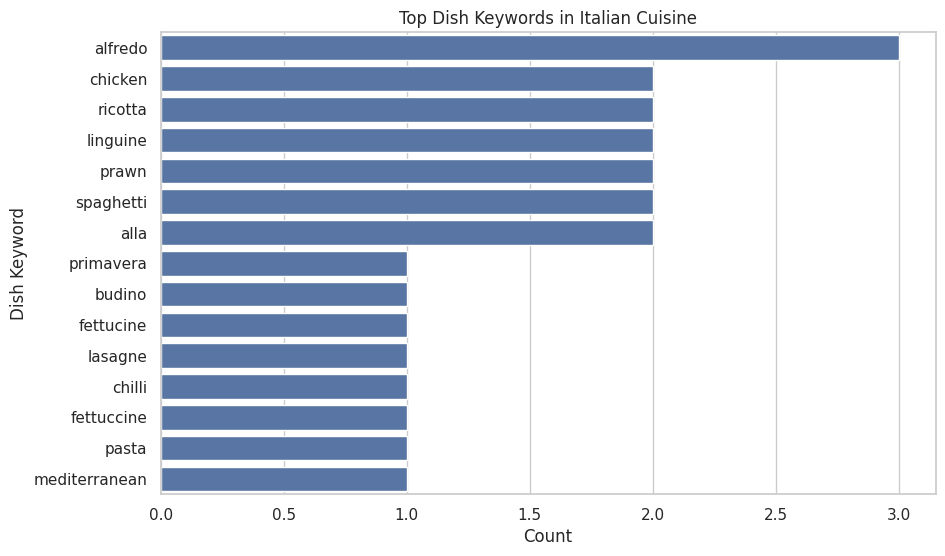


Cuisine: Indian

Top dish keywords:
   dish_keyword  count
6       chicken      4
3         mandi      2
12        curry      2
13         lamb      2
1        bharta      1
2          beef      1
5      omelette      1
7         handi      1
8           dal      1
4         bread      1
0       baingan      1
10       kidney      1
9           fry      1
11         bean      1
14      biryani      1


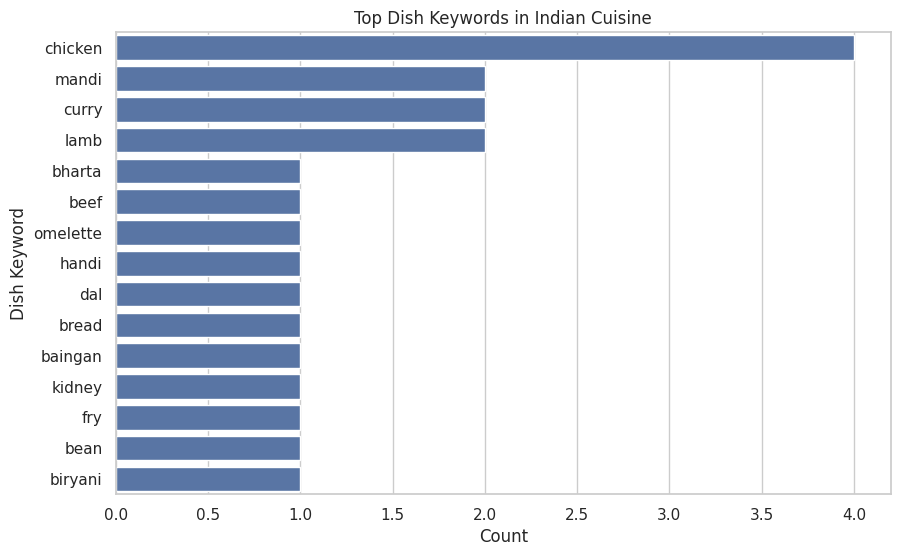


Cuisine: American

Top dish keywords:
   dish_keyword  count
1       chicken      5
20       cheese      4
34      roasted      4
37     potatoes      4
25    chocolate      3
24          pie      3
15          mac      3
18     sandwich      2
7          pork      2
36       mashed      2
35      carrots      2
30        cream      2
46        fudge      2
5      pancakes      2
62       peanut      2


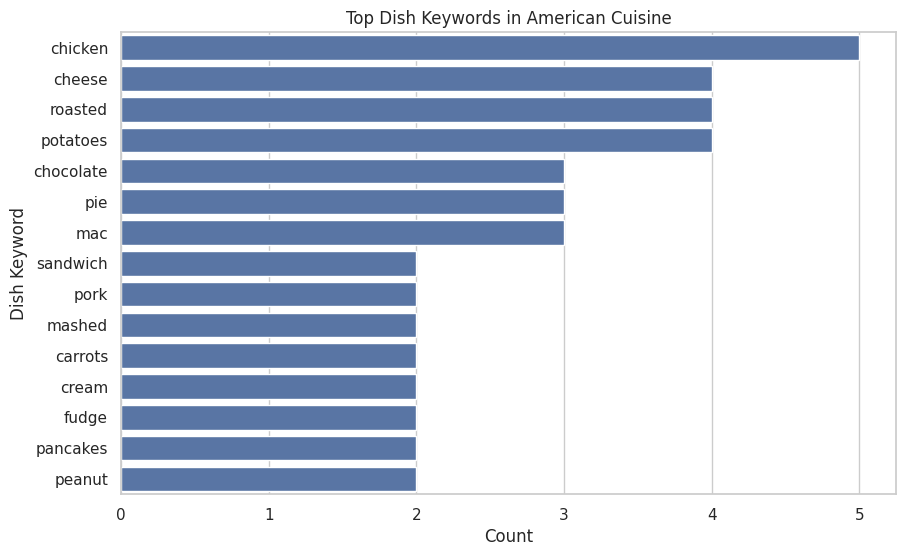


Cuisine: Mexican

Top dish keywords:
   dish_keyword  count
6         tacos      2
7       chicken      2
0       braised      1
1          beef      1
3         cajun      1
2        chilli      1
5          fish      1
4        spiced      1
8     enchilada      1
9     casserole      1
10     chickpea      1
11      fajitas      1
12        crock      1
13          pot      1
14        baked      1


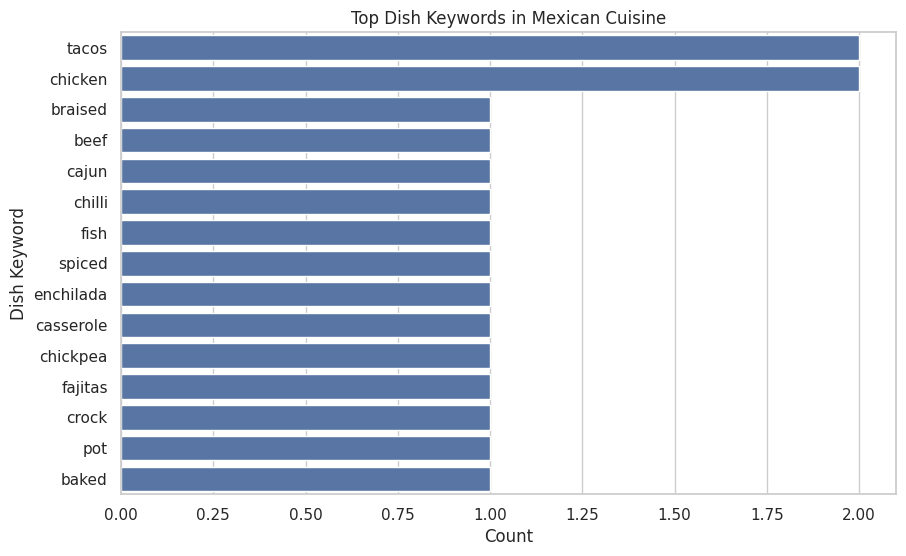

In [ ]:
# Count dish keywords from meal titles
# break titles into words and remove generic seasoning words

for cuisine_name in selected_planA_cuisines:
    print("\n" + "=" * 70)
    print("Cuisine:", cuisine_name)
    print("=" * 70)

    area_name = available_area_map[cuisine_name]
    meals = get_area_meals(area_name)

    word_count = {}

    for meal in meals:
        title = meal["strMeal"].lower()

        title = title.replace("-", " ")
        title = title.replace("&", " ")
        title = title.replace("/", " ")
        title = title.replace("(", " ")
        title = title.replace(")", " ")
        title = title.replace(",", " ")
        title = title.replace(".", " ")

        words = title.split()

        for w in words:
            if len(w) > 2 and w not in dish_stopwords:
                if w in word_count:
                    word_count[w] = word_count[w] + 1
                else:
                    word_count[w] = 1

    word_df = pd.DataFrame({
        "dish_keyword": list(word_count.keys()),
        "count": list(word_count.values())
    })

    word_df = word_df.sort_values("count", ascending=False)

    print("\nTop dish keywords:")
    print(word_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=word_df.head(15), x="count", y="dish_keyword")
    plt.title("Top Dish Keywords in " + cuisine_name + " Cuisine")
    plt.xlabel("Count")
    plt.ylabel("Dish Keyword")
    plt.show()


Cuisine: Japanese

Top dish phrases:
          dish_phrase  count
0     chicken karaage      1
1      honey teriyaki      1
2     teriyaki salmon      1
3      japanese gohan      1
4          gohan rice      1
5   japanese katsudon      1
6       katsu chicken      1
7       chicken curry      1
8    teriyaki chicken      1
9   chicken casserole      1
10      tonkatsu pork      1
11          yaki udon      1


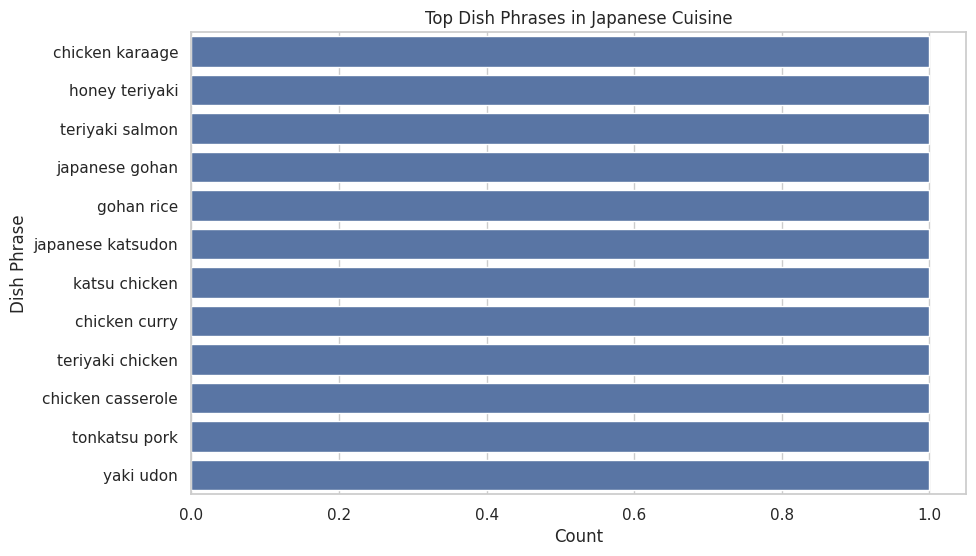


Cuisine: Thai

Top dish phrases:
        dish_phrase  count
21       thai prawn      2
17         stir fry      2
64      soup prawns      2
61          tom yum      2
29     thai chicken      2
36       thai curry      2
1       noodles pad      1
0   drunken noodles      1
6      stew noodles      1
2           pad kee      1
9           pad see      1
10         pad thai      1
12    chicken curry      1
11   panang chicken      1
13      curry kaeng      1


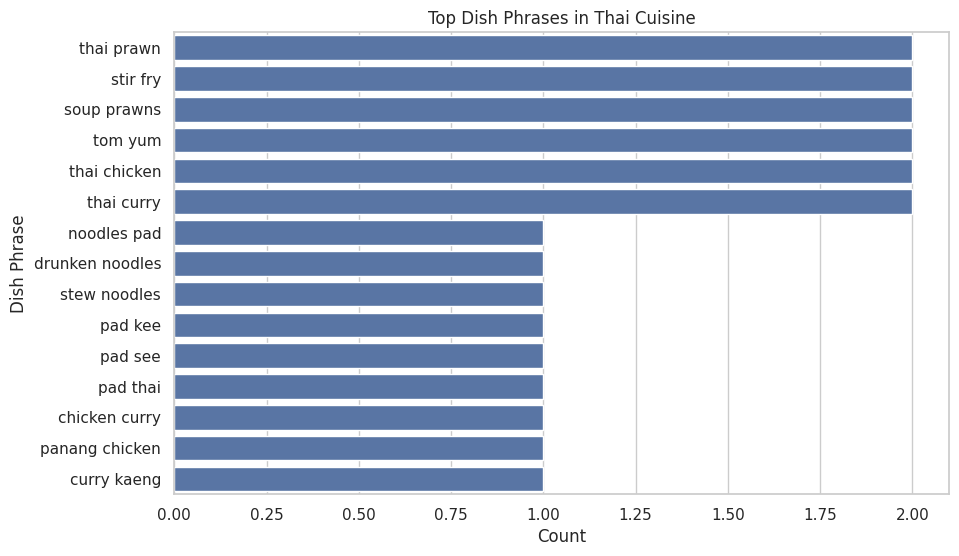


Cuisine: Italian

Top dish phrases:
            dish_phrase  count
0        budino ricotta      1
1       chicken alfredo      1
2     alfredo primavera      1
3          chilli prawn      1
4        prawn linguine      1
5    fettuccine alfredo      1
6     fettucine alfredo      1
7   mediterranean pasta      1
8           pasta salad      1
9             osso buco      1
10            buco alla      1
11        alla milanese      1
12  pilchard puttanesca      1
13        pizza express      1
14   express margherita      1


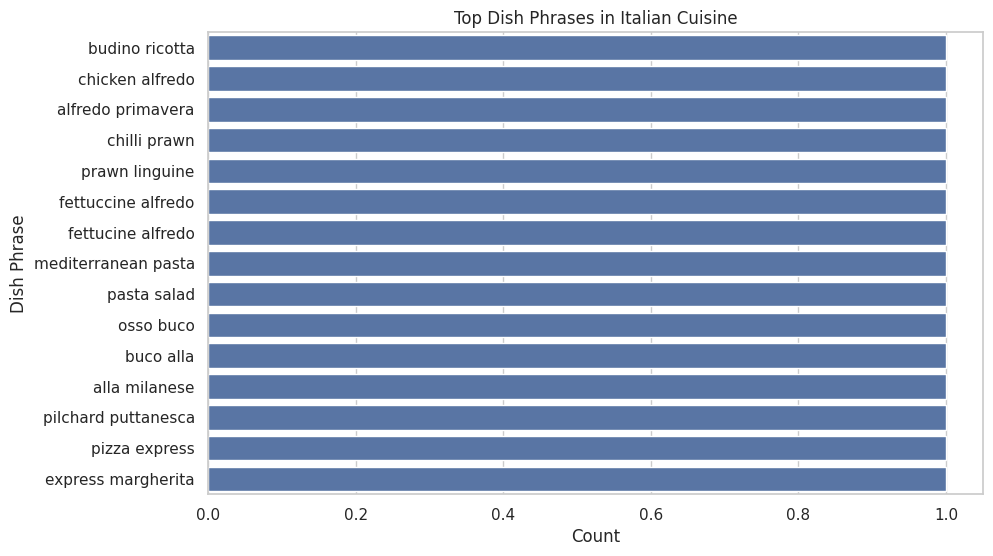


Cuisine: Indian

Top dish phrases:
        dish_phrase  count
0    baingan bharta      1
1        beef mandi      1
2    bread omelette      1
3     chicken handi      1
4     chicken mandi      1
5           dal fry      1
6       kidney bean      1
7        bean curry      1
8      lamb biryani      1
9        lamb rogan      1
10       rogan josh      1
11     matar paneer      1
12    nutty chicken      1
13    chicken curry      1
14  recheado masala      1


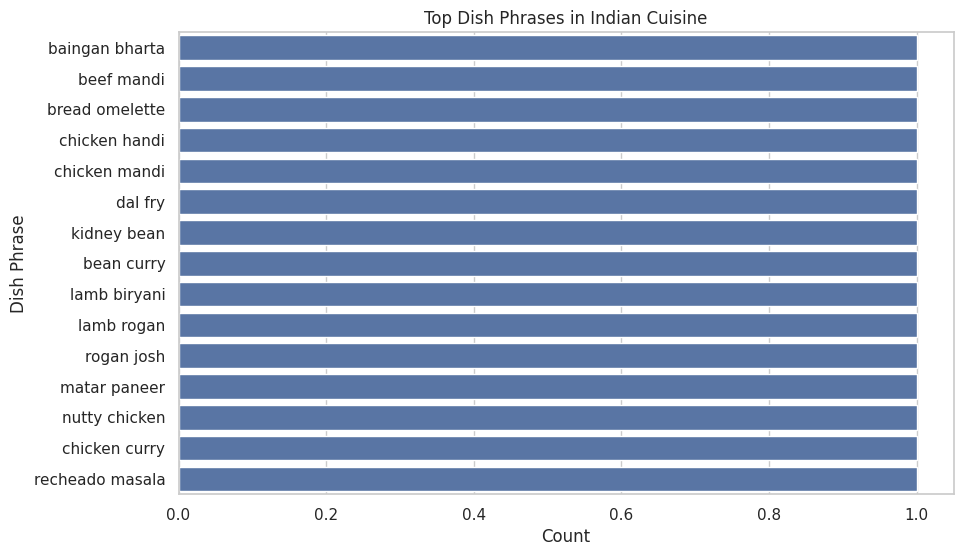


Cuisine: American

Top dish phrases:
         dish_phrase  count
15        mac cheese      2
22      cream cheese      2
27   roasted carrots      2
29   mashed potatoes      2
2   halloumi burgers      1
0     minute chicken      1
5        pork sloppy      1
6        sloppy joes      1
8        brisket pot      1
7       beef brisket      1
10           big mac      1
11         chick fil      1
12      fil sandwich      1
9          pot roast      1
13    chicken fajita      1


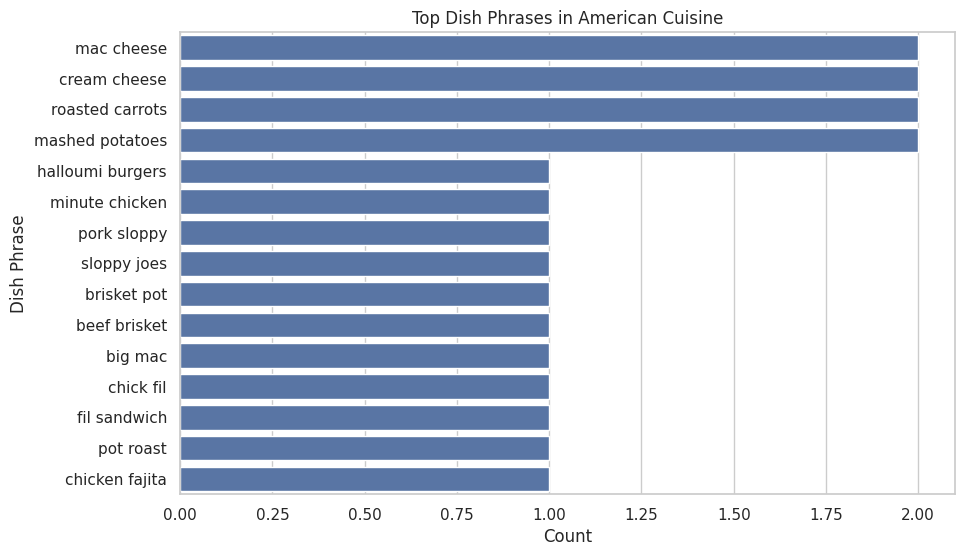


Cuisine: Mexican

Top dish phrases:
            dish_phrase  count
0          braised beef      1
1           beef chilli      1
2          cajun spiced      1
3           spiced fish      1
4            fish tacos      1
5     chicken enchilada      1
6   enchilada casserole      1
7      chickpea fajitas      1
8             crock pot      1
9           pot chicken      1
10        chicken baked      1
11          baked tacos      1
12         stuffed bell      1
13         bell peppers      1
14       peppers quinoa      1


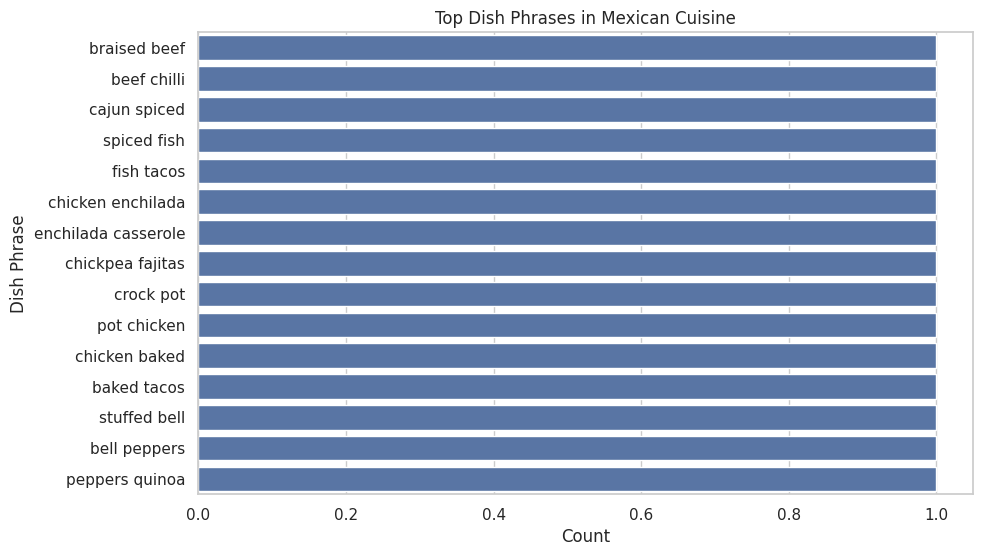

In [ ]:
# Count dish phrases (bigrams)
# This is more like actual dish-type signals than single words


for cuisine_name in selected_planA_cuisines:
    print("\n" + "=" * 70)
    print("Cuisine:", cuisine_name)
    print("=" * 70)

    area_name = available_area_map[cuisine_name]
    meals = get_area_meals(area_name)

    bigram_count = {}

    for meal in meals:
        title = meal["strMeal"].lower()

        title = title.replace("-", " ")
        title = title.replace("&", " ")
        title = title.replace("/", " ")
        title = title.replace("(", " ")
        title = title.replace(")", " ")
        title = title.replace(",", " ")
        title = title.replace(".", " ")

        words = title.split()

        clean_words = []
        for w in words:
            if len(w) > 2 and w not in dish_stopwords:
                clean_words.append(w)

        for i in range(len(clean_words) - 1):
            bg = clean_words[i] + " " + clean_words[i + 1]

            if bg in bigram_count:
                bigram_count[bg] = bigram_count[bg] + 1
            else:
                bigram_count[bg] = 1

    bigram_df = pd.DataFrame({
        "dish_phrase": list(bigram_count.keys()),
        "count": list(bigram_count.values())
    })

    bigram_df = bigram_df.sort_values("count", ascending=False)

    print("\nTop dish phrases:")
    print(bigram_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=bigram_df.head(15), x="count", y="dish_phrase")
    plt.title("Top Dish Phrases in " + cuisine_name + " Cuisine")
    plt.xlabel("Count")
    plt.ylabel("Dish Phrase")
    plt.show()